## 20251009 Check $Z_\mathrm{gas}$-$\Sigma_\mathrm{SFR}$ relation

STEP 1: Collecting data from all galaxies for HII regions...
  IC3392: HII=14884 pixels
  NGC4064: HII=6820 pixels
  NGC4064: HII=6820 pixels
  NGC4192: HII=145934 pixels
  NGC4293: HII=3854 pixels
  NGC4192: HII=145934 pixels
  NGC4293: HII=3854 pixels
  NGC4298: HII=156350 pixels
  NGC4330: HII=42566 pixels
  NGC4383: excluded from Σ_*-binned analysis
  NGC4298: HII=156350 pixels
  NGC4330: HII=42566 pixels
  NGC4383: excluded from Σ_*-binned analysis
  NGC4396: HII=81728 pixels
  NGC4419: HII=6886 pixels
  NGC4396: HII=81728 pixels
  NGC4419: HII=6886 pixels
  NGC4457: HII=6000 pixels
  NGC4457: HII=6000 pixels
  NGC4501: HII=260854 pixels
  NGC4522: HII=39354 pixels
  NGC4501: HII=260854 pixels
  NGC4522: HII=39354 pixels
  NGC4694: HII=2585 pixels
  NGC4698: HII=10042 pixels
  NGC4694: HII=2585 pixels
  NGC4698: HII=10042 pixels

Total combined pixels (HII): 777857

STEP 2: Defining 8 Σ_* bins with equal width based on data range

Σ_* Statistics:
  Min: 5.986
  Max: 9.787
  Range:

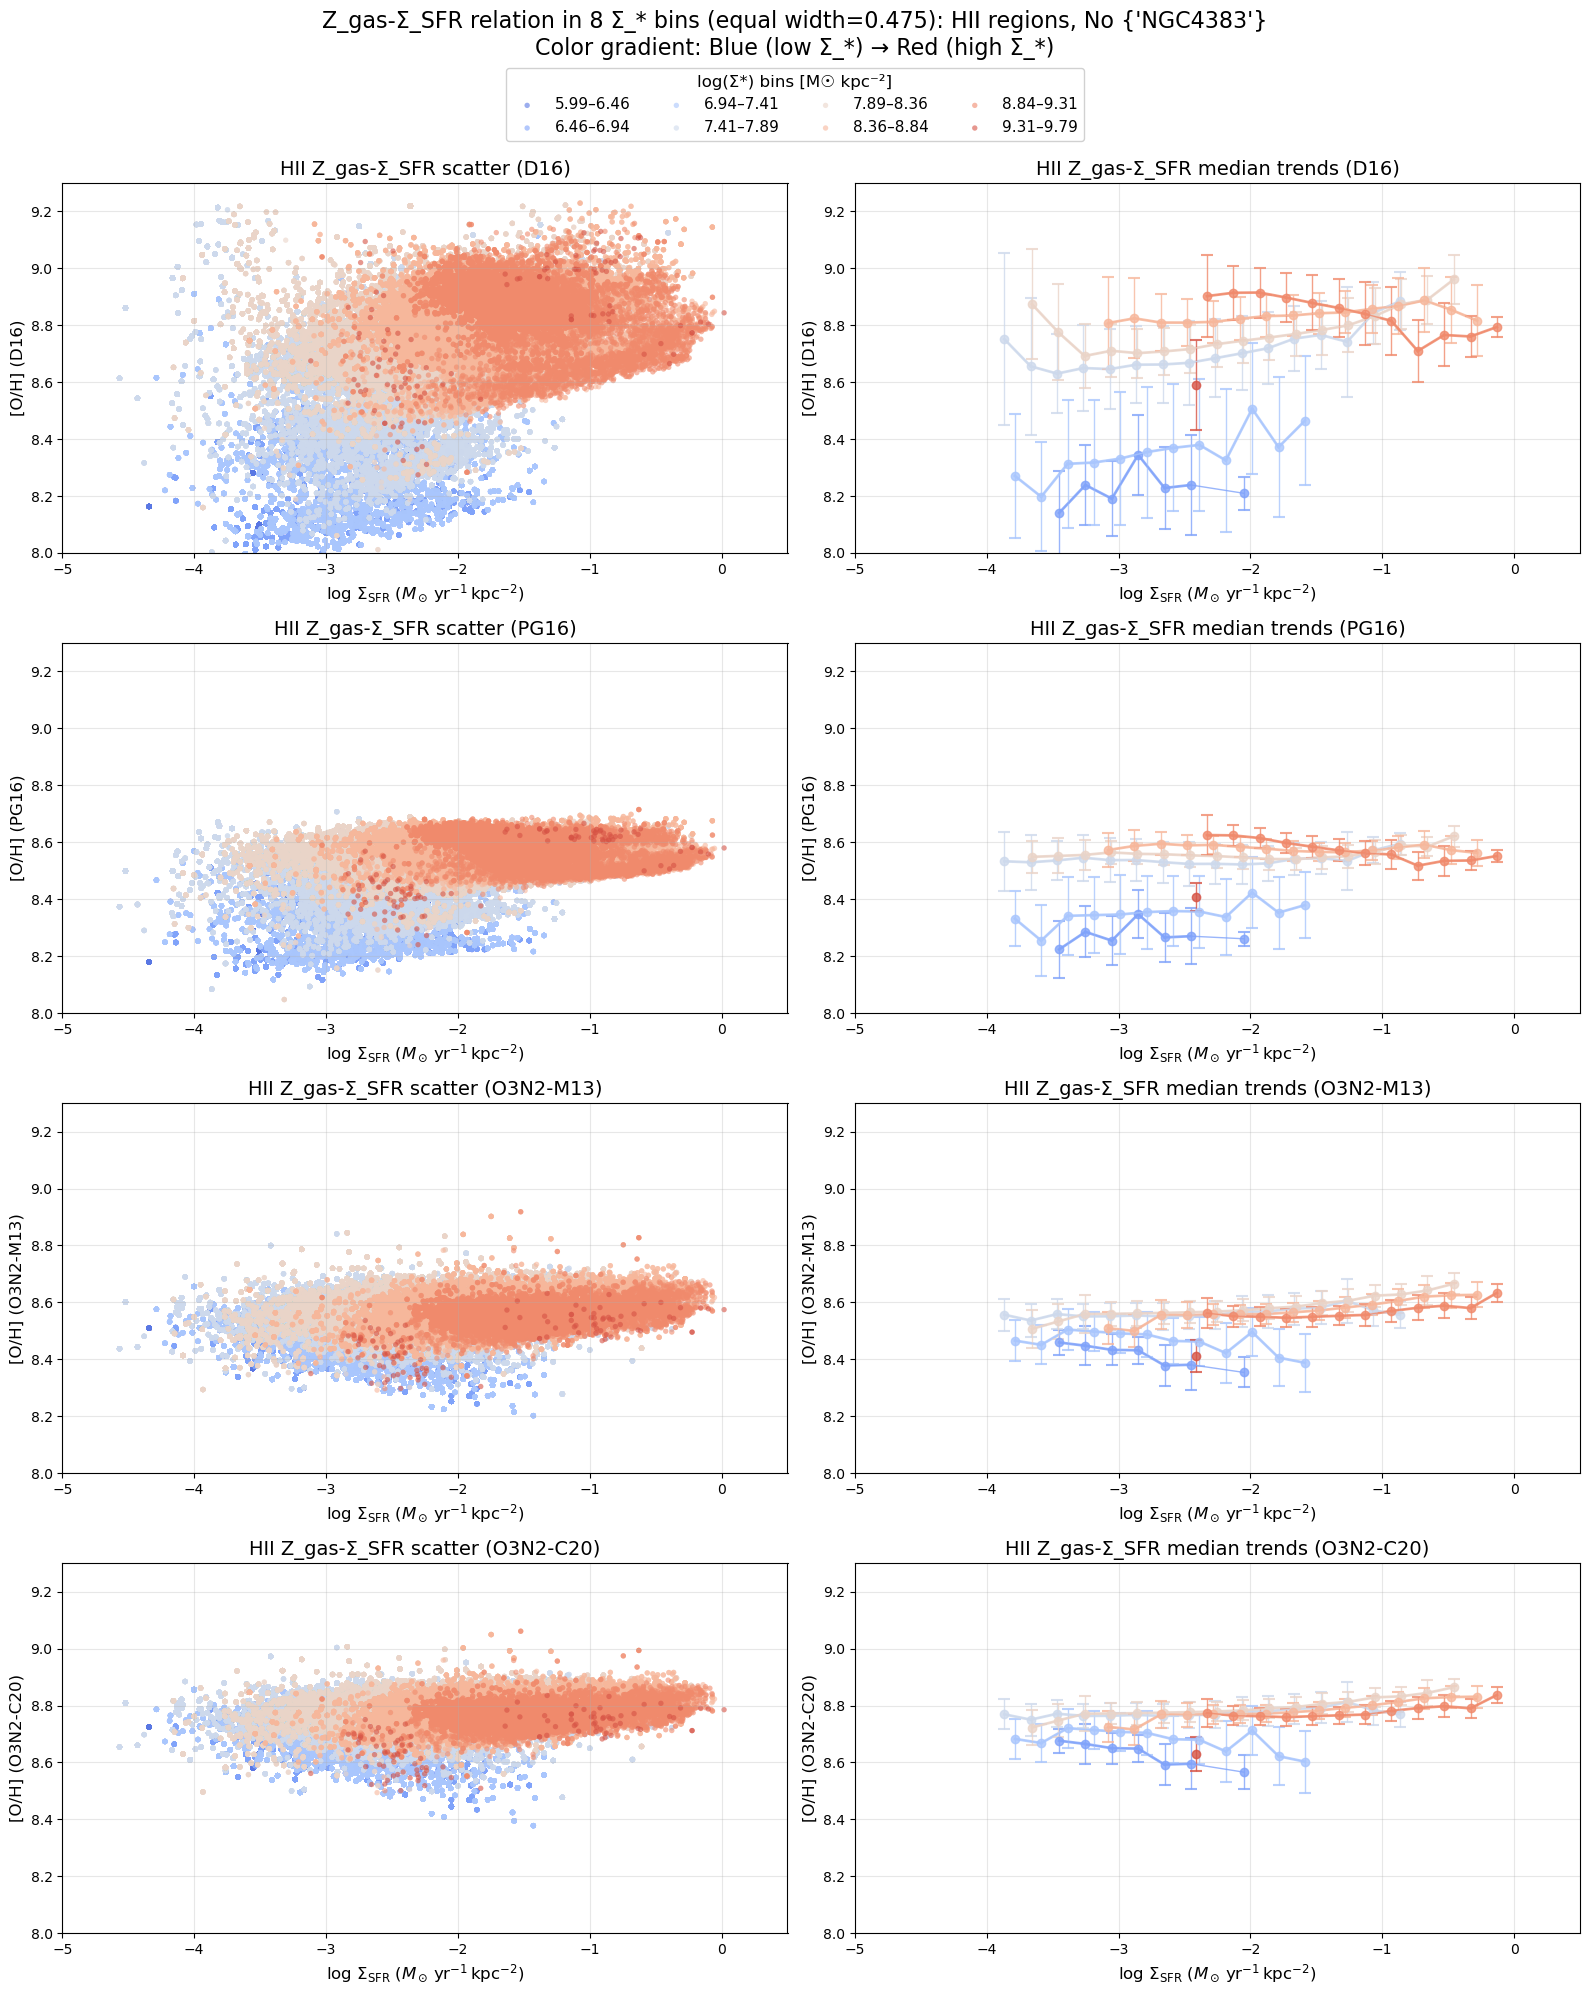


COMPLETED: 8-bin Σ_* analysis for Z_gas-Σ_SFR relation
Successfully created combined 4x2 subplot figure showing HII regions from 13 galaxies
Galaxies included: IC3392, NGC4064, NGC4192, NGC4293, NGC4298, NGC4330, NGC4396, NGC4419, NGC4457, NGC4501, NGC4522, NGC4694, NGC4698
Excluded: NGC4383

Bin summary (8 equal-width bins, width=0.475 dex):
  Σ_* range: 5.986 to 9.787
  Bin 1: 5.99–6.46
  Bin 2: 6.46–6.94
  Bin 3: 6.94–7.41
  Bin 4: 7.41–7.89
  Bin 5: 7.89–8.36
  Bin 6: 8.36–8.84
  Bin 7: 8.84–9.31
  Bin 8: 9.31–9.79


In [1]:
# ------------------------------------------------------------------
# Combined Analysis: Z_gas-Σ_SFR relation in 3 Σ_* bins - HII regions only
# Using 1-sigma binning: Low (<median-1σ), Medium (±1σ), High (>median+1σ)
# Collect all spaxels from all galaxies
# 4 rows x 2 columns: Each row shows 1 indicator (scatter on left, median on right)
# 4 calibrations: D16, PG16, O3N2-M13, O3N2-C20
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
import scipy.stats as stats

def load_maps_all_calibrations(gal):
    """Load all metallicity calibrations for HII regions"""
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        # HII regions
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_d16_HII = h['O_H_D16_HII'].data
        oh_pg16_HII = h['O_H_PG16_HII'].data
        oh_o3n2_m13_HII = h['O_H_O3N2_M13_HII'].data
        oh_o3n2_c20_HII = h['O_H_O3N2_C20_HII'].data
    return (sigM, sigSFR_HII, oh_d16_HII, oh_pg16_HII, oh_o3n2_m13_HII, oh_o3n2_c20_HII)

def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_pixels=20):
    """Calculate median and std in SFR bins - only keep bins with >= 20 unique datapoints"""
    # Define SFR bins
    x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
    sfr_bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    sfr_bin_centers = (sfr_bin_edges[:-1] + sfr_bin_edges[1:]) / 2
    
    medians = []
    stds = []
    counts = []
    valid_centers = []
    valid_bin_indices = []
    
    for i, (bin_start, bin_end) in enumerate(zip(sfr_bin_edges[:-1], sfr_bin_edges[1:])):
        # Select data in this SFR bin
        in_sfr_bin = (x_data >= bin_start) & (x_data < bin_end)
        y_in_bin = y_data[in_sfr_bin]
        
        if len(np.unique(y_in_bin)) >= min_pixels:
            medians.append(np.median(y_in_bin))
            stds.append(np.std(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(sfr_bin_centers[i])
            valid_bin_indices.append(i)
    
    return (np.array(valid_centers), np.array(medians), np.array(stds), 
            np.array(counts), np.array(valid_bin_indices))

# Get all galaxies
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bins]

# Galaxies to exclude entirely
excluded_galaxies = {'NGC4383'}
included_galaxies = []

# ==============================================================================
# STEP 1: Collect all spaxels from all galaxies for HII regions
# ==============================================================================
all_logSigmaM_HII = []
all_logSigmaSFR_HII = []
all_oh_d16_HII = []
all_oh_pg16_HII = []
all_oh_o3n2_m13_HII = []
all_oh_o3n2_c20_HII = []

print("="*80)
print("STEP 1: Collecting data from all galaxies for HII regions...")
print("="*80)

for gal in galaxies:
    if gal in excluded_galaxies:
        print(f"  {gal}: excluded from Σ_*-binned analysis")
        continue

    bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')
    gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')

    if bin_file.exists() and gas_file.exists():
        included_galaxies.append(gal)
        # Load all data for HII regions
        (logSigmaM, logSigmaSFR_HII, oh_d16_HII, oh_pg16_HII, oh_o3n2_m13_HII, 
         oh_o3n2_c20_HII) = load_maps_all_calibrations(gal)

        # Find common spaxels for HII regions
        common_mask_HII = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & 
                           np.isfinite(oh_d16_HII) & np.isfinite(oh_pg16_HII) & 
                           np.isfinite(oh_o3n2_m13_HII) & np.isfinite(oh_o3n2_c20_HII))
        
        print(f"  {gal}: HII={np.sum(common_mask_HII)} pixels")
        
        # Append HII data
        all_logSigmaM_HII.extend(logSigmaM[common_mask_HII].flatten())
        all_logSigmaSFR_HII.extend(logSigmaSFR_HII[common_mask_HII].flatten())
        all_oh_d16_HII.extend(oh_d16_HII[common_mask_HII].flatten())
        all_oh_pg16_HII.extend(oh_pg16_HII[common_mask_HII].flatten())
        all_oh_o3n2_m13_HII.extend(oh_o3n2_m13_HII[common_mask_HII].flatten())
        all_oh_o3n2_c20_HII.extend(oh_o3n2_c20_HII[common_mask_HII].flatten())
    else:
        print(f"  {gal}: Data files not found")

# Convert to numpy arrays
all_logSigmaM_HII = np.array(all_logSigmaM_HII)
all_logSigmaSFR_HII = np.array(all_logSigmaSFR_HII)
all_oh_d16_HII = np.array(all_oh_d16_HII)
all_oh_pg16_HII = np.array(all_oh_pg16_HII)
all_oh_o3n2_m13_HII = np.array(all_oh_o3n2_m13_HII)
all_oh_o3n2_c20_HII = np.array(all_oh_o3n2_c20_HII)

print(f"\nTotal combined pixels (HII): {len(all_logSigmaM_HII)}")

# ==============================================================================
# STEP 2: Define 8 Σ_* bins with equal width based on actual data range
# ==============================================================================
print("\n" + "="*80)
print("STEP 2: Defining 8 Σ_* bins with equal width based on data range")
print("="*80)

# Calculate the actual data range
sigmaM_min = np.min(all_logSigmaM_HII)
sigmaM_max = np.max(all_logSigmaM_HII)
sigmaM_range = sigmaM_max - sigmaM_min

print(f"\nΣ_* Statistics:")
print(f"  Min: {sigmaM_min:.3f}")
print(f"  Max: {sigmaM_max:.3f}")
print(f"  Range: {sigmaM_range:.3f}")

# Define 8 Σ_* bins with equal width across the actual data range
n_bins = 8
bin_width = sigmaM_range / n_bins
sigmaM_bin_edges = np.linspace(sigmaM_min, sigmaM_max, n_bins + 1)

print(f"  Bin width: {bin_width:.3f} dex")

# Create bin labels
bin_labels = []
for i in range(n_bins):
    bin_labels.append(f'{sigmaM_bin_edges[i]:.2f}–{sigmaM_bin_edges[i+1]:.2f}')

print(f"\n8 Σ_* bins (equal width):")
for i, label in enumerate(bin_labels):
    print(f"  Bin {i+1}: {label}")

# Verify bin counts
print(f"\nPixel counts per bin:")
for i in range(n_bins):
    if i == 0:
        mask = (all_logSigmaM_HII >= sigmaM_bin_edges[i]) & (all_logSigmaM_HII < sigmaM_bin_edges[i+1])
    elif i == n_bins - 1:
        mask = (all_logSigmaM_HII >= sigmaM_bin_edges[i]) & (all_logSigmaM_HII <= sigmaM_bin_edges[i+1])
    else:
        mask = (all_logSigmaM_HII >= sigmaM_bin_edges[i]) & (all_logSigmaM_HII < sigmaM_bin_edges[i+1])
    count = np.sum(mask)
    pct = 100 * count / len(all_logSigmaM_HII) if len(all_logSigmaM_HII) > 0 else 0
    print(f"  Bin {i+1} ({bin_labels[i]}): {count} pixels ({pct:.1f}%)")

# Colors for 8 bins: gradient from blue (low Σ_*) to red (high Σ_*)
colors = plt.cm.coolwarm(np.linspace(0.1, 0.9, n_bins))

# ==============================================================================
# STEP 3: Create Z_gas-Σ_SFR plots ([O/H] vs Σ_SFR in different Σ_* bins)
# ==============================================================================
print("\n" + "="*80)
print("STEP 3: Creating Z_gas-Σ_SFR plots for 8 Σ_* bins")
print("="*80)

# Set uniform y-axis range
common_ylim = (8.0, 9.3)

print(f"\nUsing uniform y-axis range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")

# Create figure with 4 rows x 2 columns 
# Each row contains 1 indicator: column 0 for scatter, column 1 for median trends
fig, axes = plt.subplots(4, 2, figsize=(16, 20))

# Data for each calibration
calibrations = [
    (all_oh_d16_HII, 'D16'),
    (all_oh_pg16_HII, 'PG16'),
    (all_oh_o3n2_m13_HII, 'O3N2-M13'),
    (all_oh_o3n2_c20_HII, 'O3N2-C20')
]

# Create legend handles (will be populated during first row)
legend_handles = []
legend_labels = []

# Process each row (1 calibration per row)
for row_idx, (oh_data_HII, calib_name_HII) in enumerate(calibrations):
    print(f"\nProcessing {calib_name_HII} calibration for HII regions:")
    
    # Column 0: Scatter plot, Column 1: Median trends
    ax_scatter = axes[row_idx, 0]
    ax_median = axes[row_idx, 1]
    
    print(f"  HII {calib_name_HII} range: {np.min(oh_data_HII):.3f} to {np.max(oh_data_HII):.3f}")
    
    # Plot each Σ_* bin
    valid_bins = 0
    
    for i in range(n_bins):
        # HII regions processing
        if i == 0:
            in_bin_HII = (all_logSigmaM_HII >= sigmaM_bin_edges[i]) & (all_logSigmaM_HII < sigmaM_bin_edges[i+1])
        elif i == n_bins - 1:
            in_bin_HII = (all_logSigmaM_HII >= sigmaM_bin_edges[i]) & (all_logSigmaM_HII <= sigmaM_bin_edges[i+1])
        else:
            in_bin_HII = (all_logSigmaM_HII >= sigmaM_bin_edges[i]) & (all_logSigmaM_HII < sigmaM_bin_edges[i+1])
        
        n_pixels_HII = np.sum(in_bin_HII)
        
        if n_pixels_HII >= 10:  # Process bins with enough pixels
            # Get data for this bin - NOW: x=Σ_SFR, y=[O/H]
            x_bin_HII = all_logSigmaSFR_HII[in_bin_HII]
            y_bin_HII = oh_data_HII[in_bin_HII]
            
            # Scatter plot
            scatter_hii = ax_scatter.scatter(x_bin_HII, y_bin_HII, c=[colors[i]], s=15, alpha=0.6, 
                                 edgecolors='none', rasterized=True)
            
            # Collect legend info only from first row
            if row_idx == 0 and len(legend_handles) < n_bins:
                legend_handles.append(scatter_hii)
                legend_labels.append(bin_labels[i])
            
            # Median trends
            sfr_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(
                x_bin_HII, y_bin_HII, bin_width=0.2, min_pixels=20)
            
            if len(sfr_centers_HII) > 0:
                ax_median.errorbar(sfr_centers_HII, medians_HII, yerr=stds_HII, 
                           color=colors[i], marker='o', markersize=6, 
                           linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
                
                # Add lines between adjacent bins
                for j in range(len(valid_bin_indices_HII) - 1):
                    current_bin_idx = valid_bin_indices_HII[j]
                    next_bin_idx = valid_bin_indices_HII[j + 1]
                    if next_bin_idx - current_bin_idx == 1:
                        ax_median.plot([sfr_centers_HII[j], sfr_centers_HII[j + 1]], 
                               [medians_HII[j], medians_HII[j + 1]], 
                               color=colors[i], linewidth=2, alpha=0.8)
                valid_bins += 1
    
    # Format scatter plot
    ax_scatter.set_xlabel(r'$\log\,\Sigma_\mathrm{SFR} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)
    ax_scatter.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
    ax_scatter.set_title(f'HII Z_gas-Σ_SFR scatter ({calib_name_HII})', fontsize=14)
    ax_scatter.grid(True, alpha=0.3)
    ax_scatter.set_xlim(-5.0, 0.5)
    ax_scatter.set_ylim(common_ylim)
    
    # Format median trends plot
    ax_median.set_xlabel(r'$\log\,\Sigma_\mathrm{SFR} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)
    ax_median.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
    ax_median.set_title(f'HII Z_gas-Σ_SFR median trends ({calib_name_HII})', fontsize=14)
    ax_median.grid(True, alpha=0.3)
    ax_median.set_xlim(-5.0, 0.5)
    ax_median.set_ylim(common_ylim)
    
    print(f"  Total valid bins: {valid_bins}")

# Add overall title and adjust layout
fig.suptitle(f'Z_gas-Σ_SFR relation in 8 Σ_* bins (equal width={bin_width:.3f}): HII regions, No {excluded_galaxies}\n' + 
             f'Color gradient: Blue (low Σ_*) → Red (high Σ_*)', 
             fontsize=16, y=0.995)

# Add shared legend at the top horizontally
fig.legend(legend_handles, legend_labels, loc='upper center', bbox_to_anchor=(0.5, 0.97),
          ncol=4, fontsize=11, framealpha=0.9, 
          title='log(Σ*) bins [M☉ kpc⁻²]', title_fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Leave space for suptitle and legend
# plt.savefig('Combined_Zgas_SigmaSFR_HII_8bins_equalwidth_4x2grid.png', dpi=300, bbox_inches='tight')
# plt.savefig('Combined_Zgas_SigmaSFR_HII_8bins_equalwidth_4x2grid.pdf', bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("COMPLETED: 8-bin Σ_* analysis for Z_gas-Σ_SFR relation")
print("="*80)
print(f"Successfully created combined 4x2 subplot figure showing HII regions from {len(included_galaxies)} galaxies")
print(f"Galaxies included: {', '.join(included_galaxies)}")
print(f"Excluded: {', '.join(sorted(excluded_galaxies))}")
print(f"\nBin summary (8 equal-width bins, width={bin_width:.3f} dex):")
print(f"  Σ_* range: {sigmaM_min:.3f} to {sigmaM_max:.3f}")
for i, label in enumerate(bin_labels):
    print(f"  Bin {i+1}: {label}")


STEP 1: Collecting combined data from all galaxies for background...
  IC3392: HII=14884 pixels
  NGC4064: HII=6820 pixels
  NGC4192: HII=145934 pixels
  NGC4064: HII=6820 pixels
  NGC4192: HII=145934 pixels
  NGC4293: HII=3854 pixels
  NGC4298: HII=156350 pixels
  NGC4293: HII=3854 pixels
  NGC4298: HII=156350 pixels
  NGC4330: HII=42566 pixels
  NGC4383: excluded from combined dataset
  NGC4396: HII=81728 pixels
  NGC4330: HII=42566 pixels
  NGC4383: excluded from combined dataset
  NGC4396: HII=81728 pixels
  NGC4419: HII=6886 pixels
  NGC4457: HII=6000 pixels
  NGC4419: HII=6886 pixels
  NGC4457: HII=6000 pixels
  NGC4501: HII=260854 pixels
  NGC4522: HII=39354 pixels
  NGC4501: HII=260854 pixels
  NGC4522: HII=39354 pixels
  NGC4694: HII=2585 pixels
  NGC4698: HII=10042 pixels

Total combined pixels (HII): 777857

Using uniform y-axis range: 8.0 to 9.3

STEP 2: Processing individual galaxies...

Processing galaxy: IC3392
  NGC4694: HII=2585 pixels
  NGC4698: HII=10042 pixels

Tota

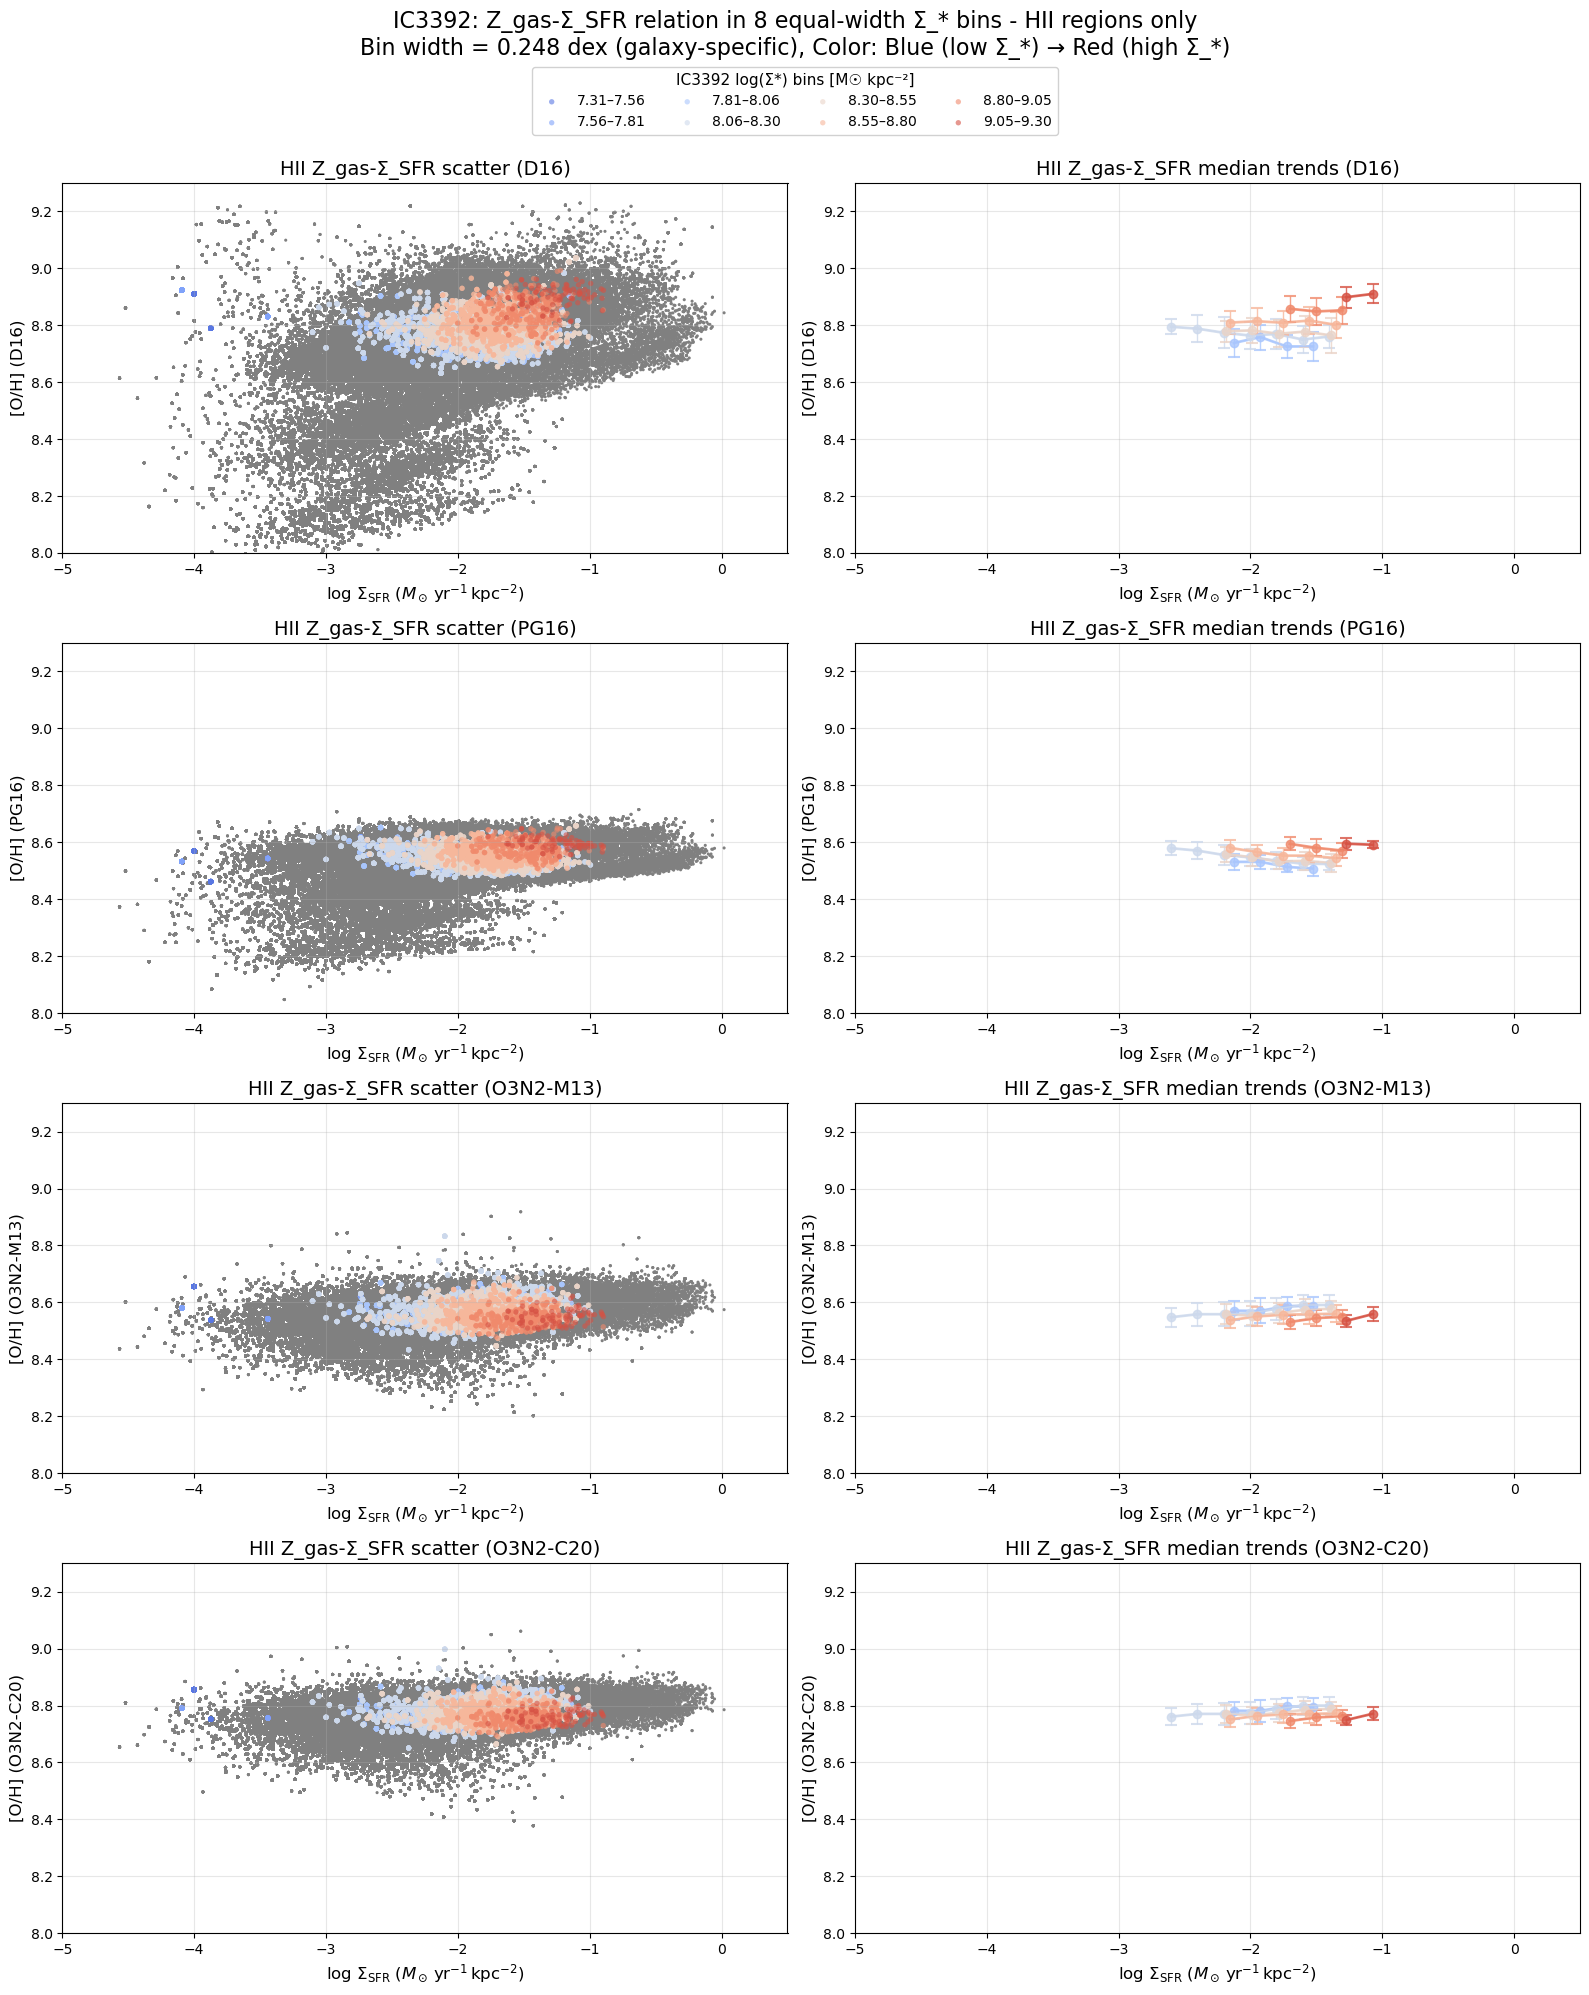


Successfully created 4x2 subplot figure for IC3392
Binning summary:
  Number of bins: 8
  Bin width: 0.248 dex (equal width)
  Σ_* range: 7.310 to 9.297

Processing galaxy: NGC4064
Total HII pixels with all calibrations: 6820

NGC4064 Σ_* range:
  Min: 7.005
  Max: 9.351
  Range: 2.346

NGC4064 Bin width: 0.293

NGC4064 8 equal-width Σ_* bins:
  Bin edges: ['7.005', '7.298', '7.591', '7.885', '8.178', '8.471', '8.765', '9.058', '9.351']
  Bin 1: 7.00–7.30
  Bin 2: 7.30–7.59
  Bin 3: 7.59–7.88
  Bin 4: 7.88–8.18
  Bin 5: 8.18–8.47
  Bin 6: 8.47–8.76
  Bin 7: 8.76–9.06
  Bin 8: 9.06–9.35

NGC4064 Pixel counts per bin:
  Bin 1 (7.00–7.30): 143 pixels (2.1%)
  Bin 2 (7.30–7.59): 96 pixels (1.4%)
  Bin 3 (7.59–7.88): 113 pixels (1.7%)
  Bin 4 (7.88–8.18): 247 pixels (3.6%)
  Bin 5 (8.18–8.47): 1686 pixels (24.7%)
  Bin 6 (8.47–8.76): 3087 pixels (45.3%)
  Bin 7 (8.76–9.06): 1338 pixels (19.6%)
  Bin 8 (9.06–9.35): 110 pixels (1.6%)

Total pixels in bins: 6820 (should match 6820)

Processin

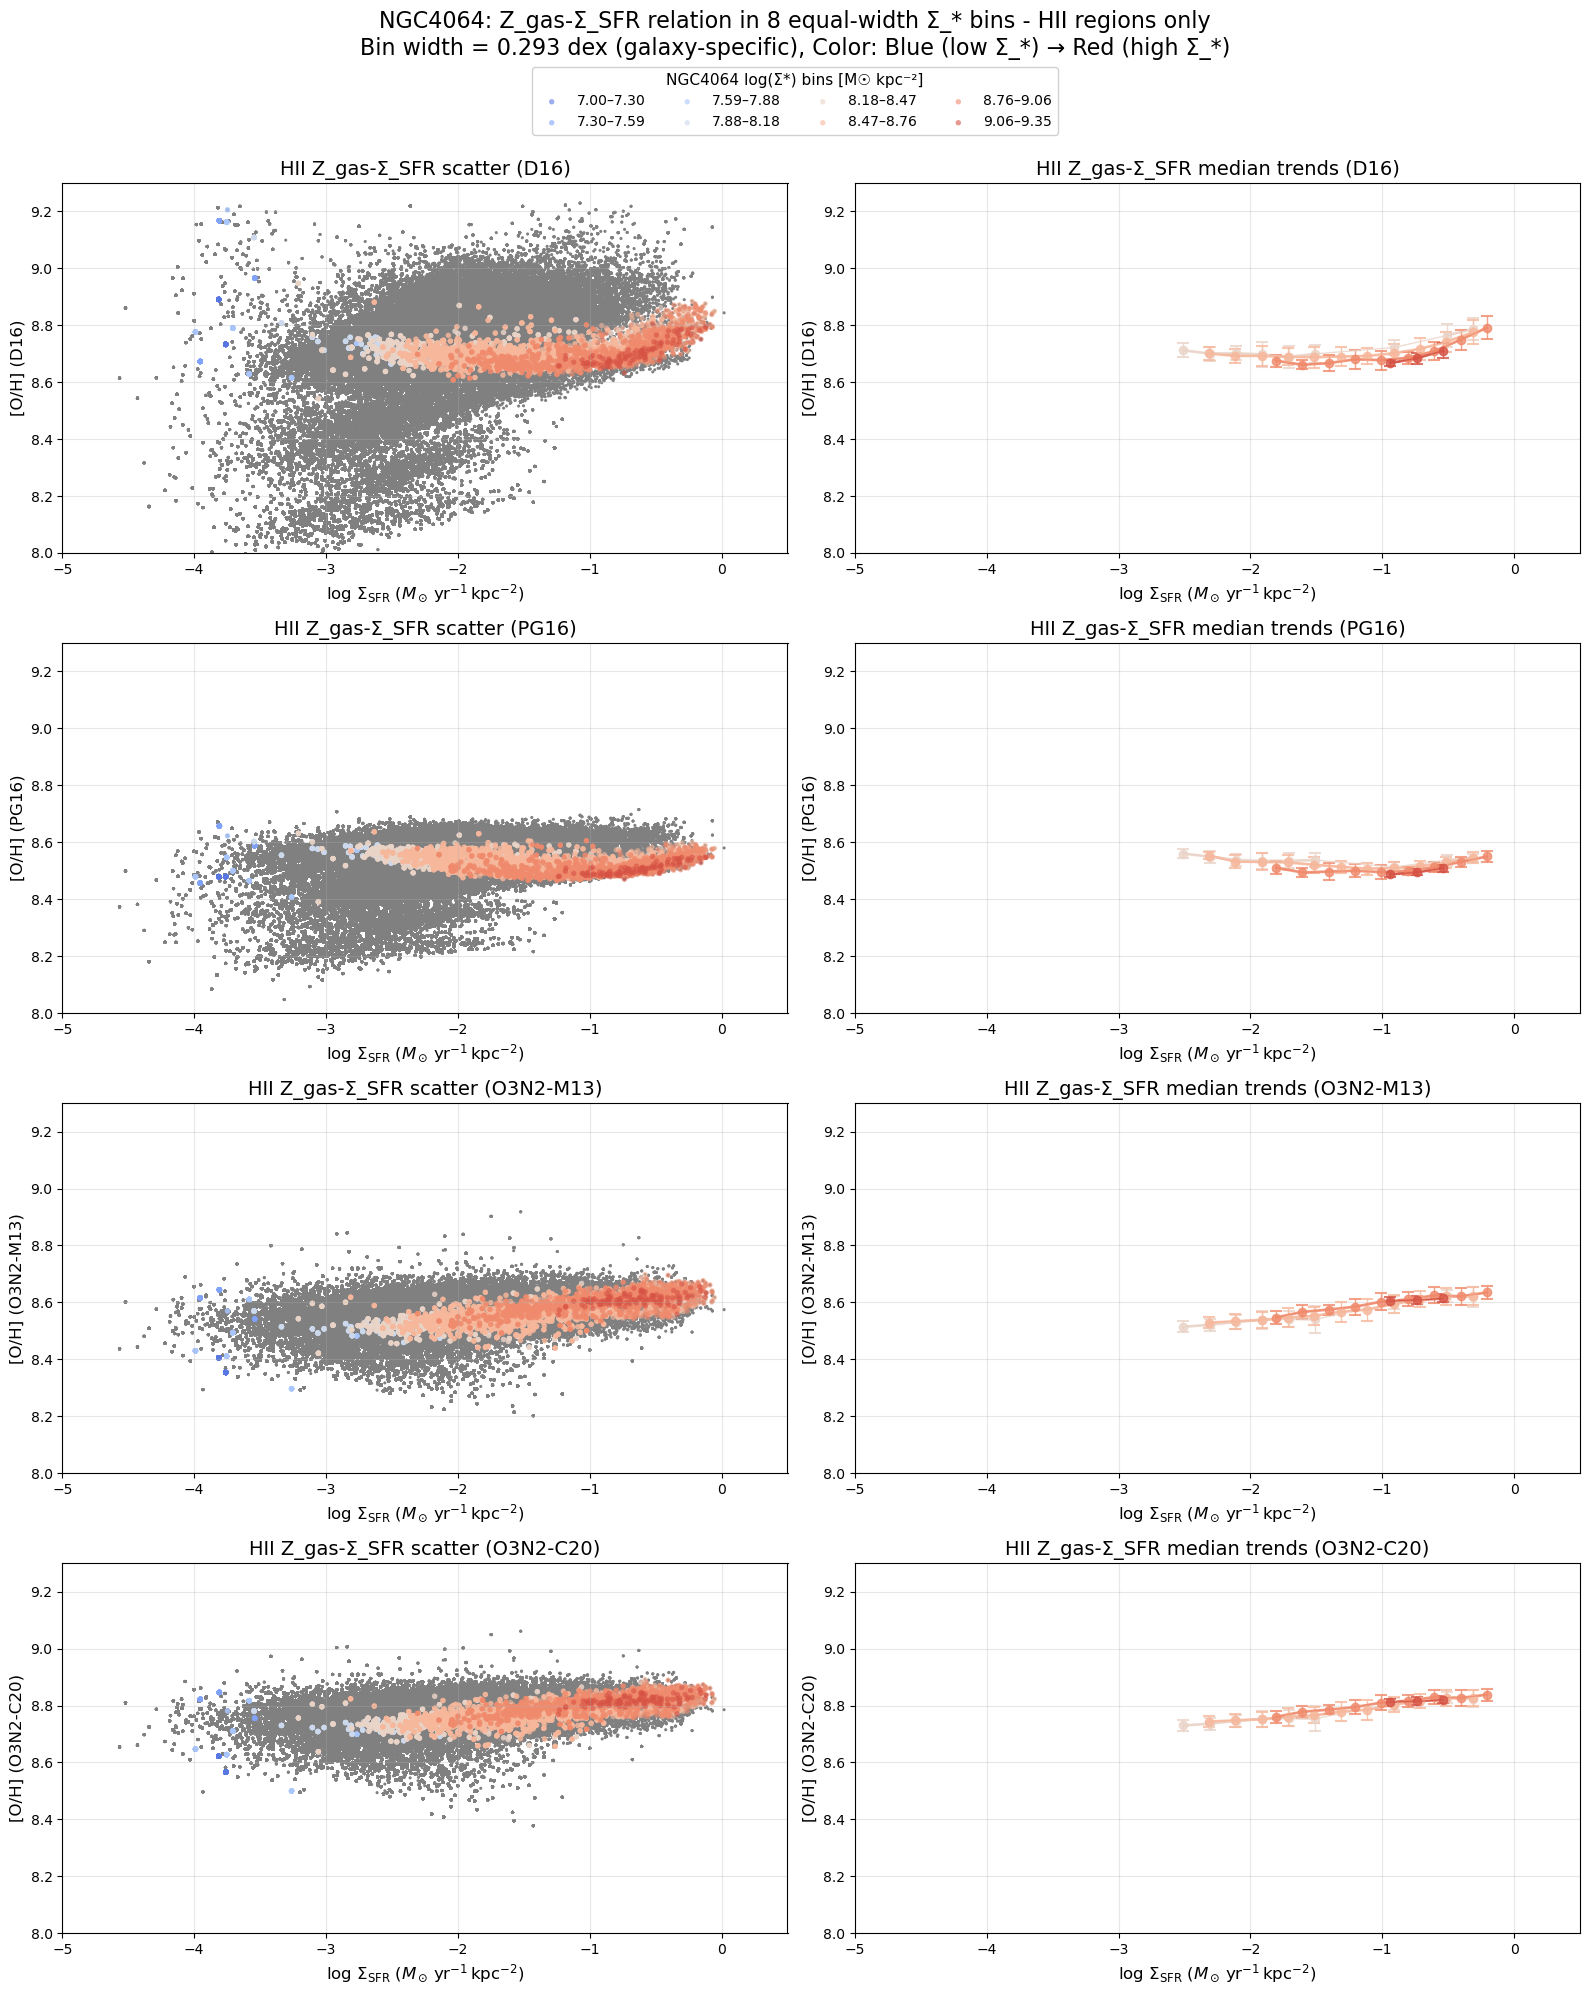


Successfully created 4x2 subplot figure for NGC4064
Binning summary:
  Number of bins: 8
  Bin width: 0.293 dex (equal width)
  Σ_* range: 7.005 to 9.351

Processing galaxy: NGC4192
Total HII pixels with all calibrations: 145934

NGC4192 Σ_* range:
  Min: 6.797
  Max: 9.564
  Range: 2.767

NGC4192 Bin width: 0.346

NGC4192 8 equal-width Σ_* bins:
  Bin edges: ['6.797', '7.143', '7.489', '7.835', '8.181', '8.527', '8.873', '9.218', '9.564']
  Bin 1: 6.80–7.14
  Bin 2: 7.14–7.49
  Bin 3: 7.49–7.83
  Bin 4: 7.83–8.18
  Bin 5: 8.18–8.53
  Bin 6: 8.53–8.87
  Bin 7: 8.87–9.22
  Bin 8: 9.22–9.56

NGC4192 Pixel counts per bin:
  Bin 1 (6.80–7.14): 3364 pixels (2.3%)
  Bin 2 (7.14–7.49): 31171 pixels (21.4%)
  Bin 3 (7.49–7.83): 66625 pixels (45.7%)
  Bin 4 (7.83–8.18): 39089 pixels (26.8%)
  Bin 5 (8.18–8.53): 5288 pixels (3.6%)
  Bin 6 (8.53–8.87): 57 pixels (0.0%)
  Bin 7 (8.87–9.22): 301 pixels (0.2%)
  Bin 8 (9.22–9.56): 39 pixels (0.0%)

Total pixels in bins: 145934 (should match 145934)

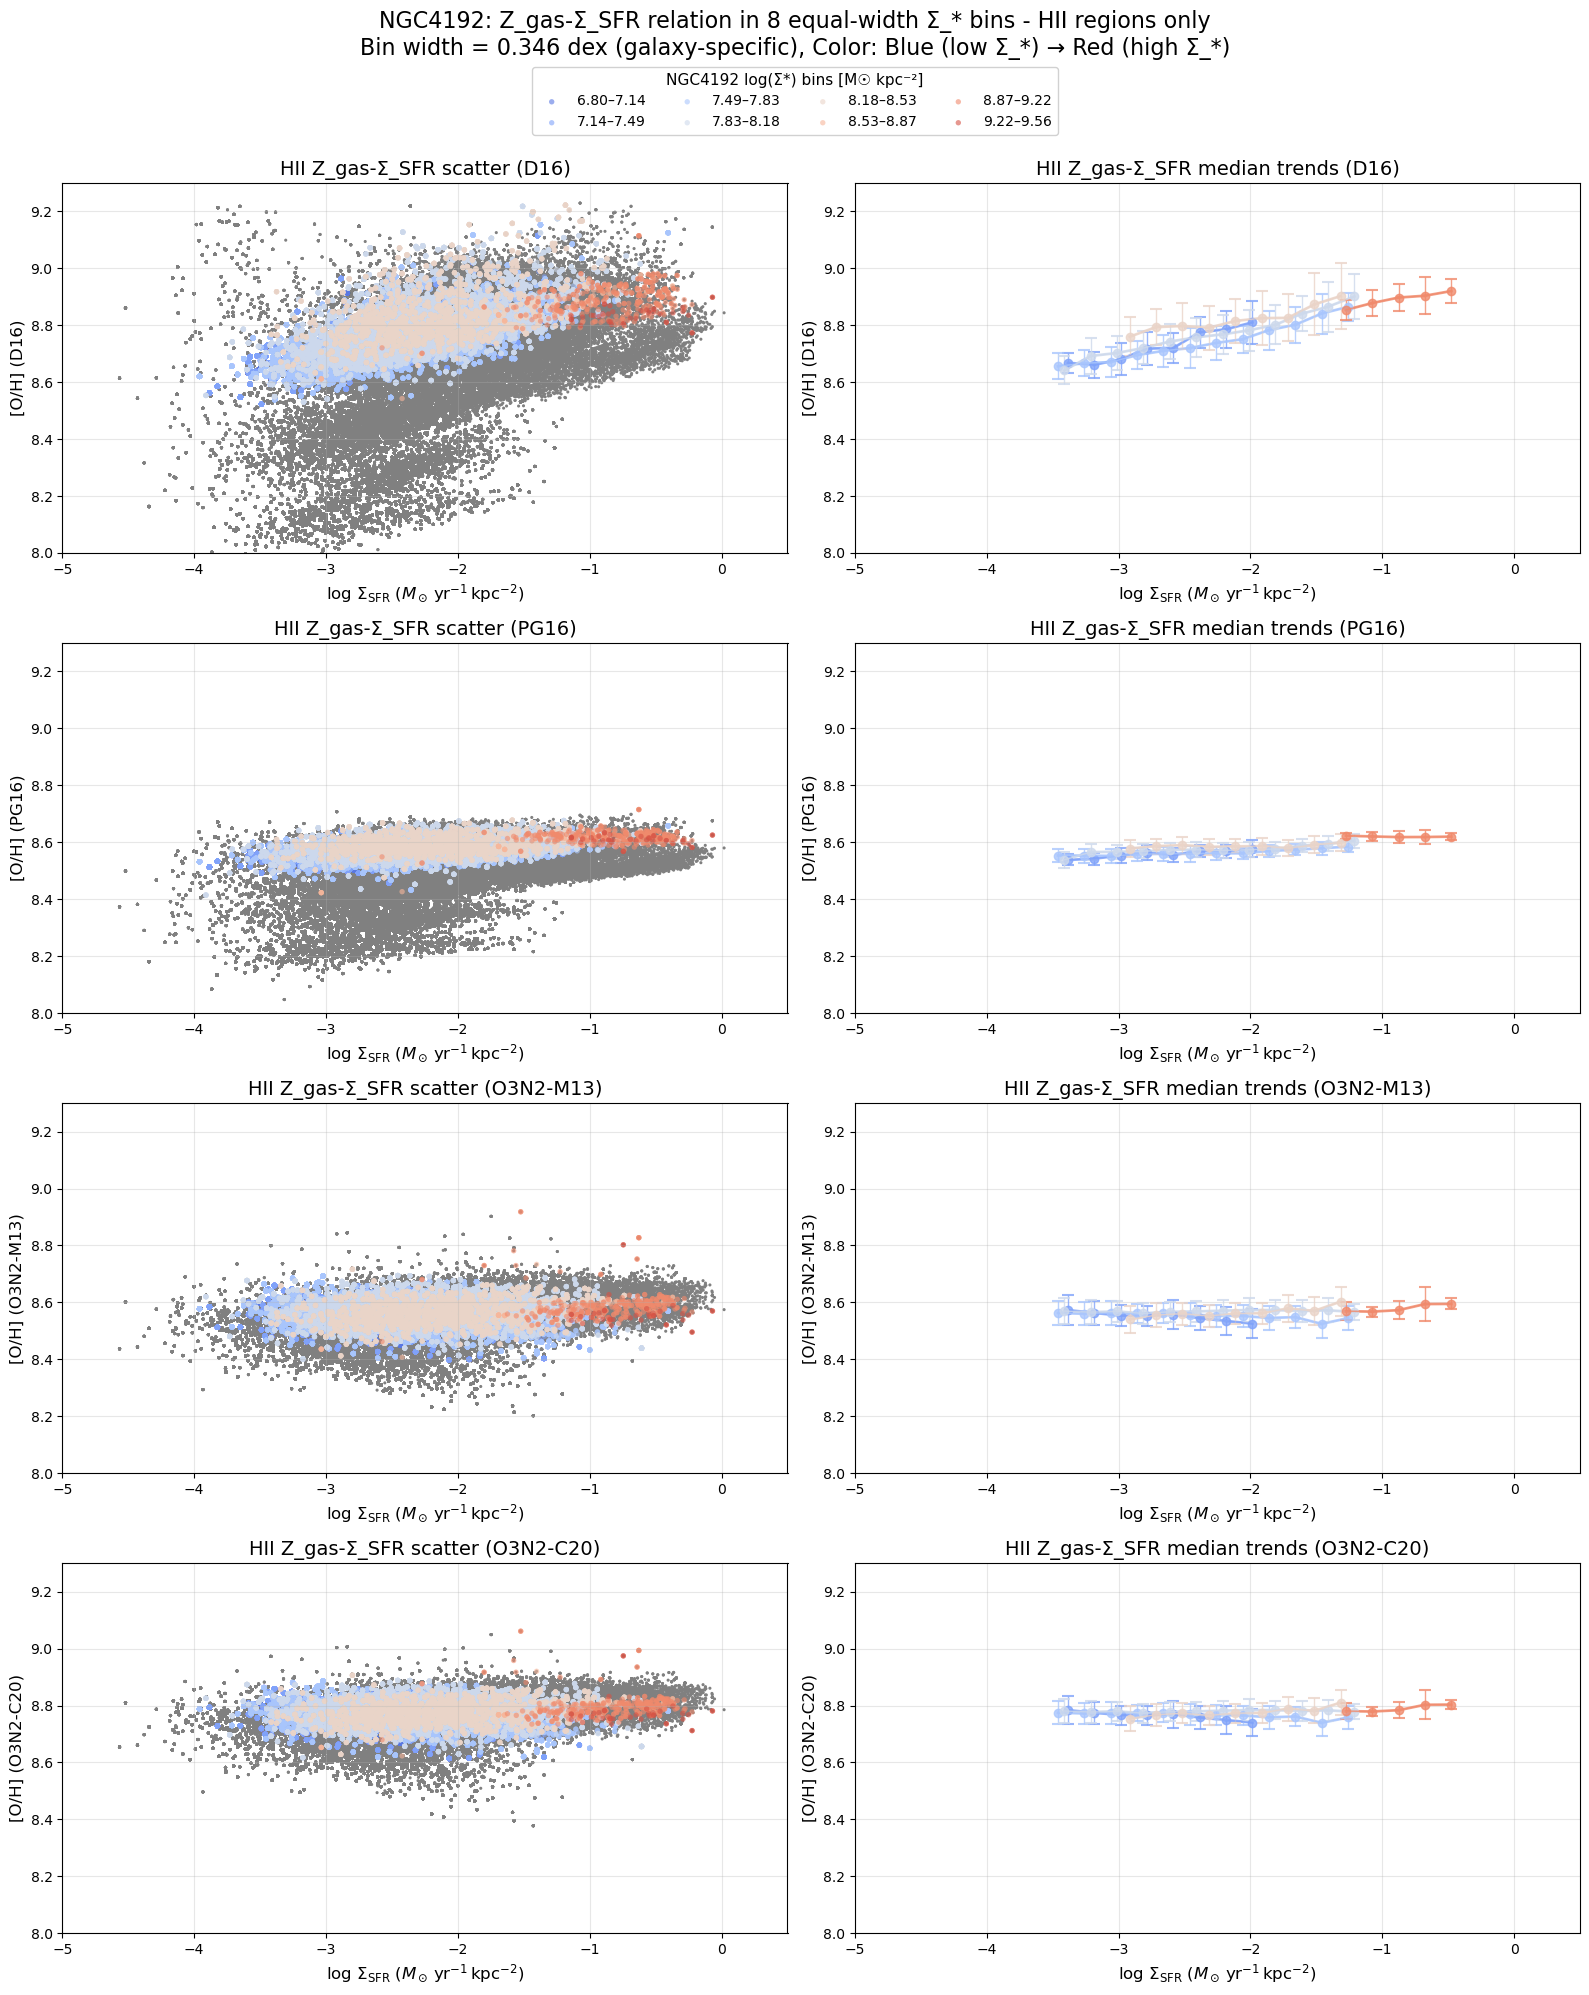


Successfully created 4x2 subplot figure for NGC4192
Binning summary:
  Number of bins: 8
  Bin width: 0.346 dex (equal width)
  Σ_* range: 6.797 to 9.564

Processing galaxy: NGC4293
Total HII pixels with all calibrations: 3854

NGC4293 Σ_* range:
  Min: 7.419
  Max: 9.082
  Range: 1.663

NGC4293 Bin width: 0.208

NGC4293 8 equal-width Σ_* bins:
  Bin edges: ['7.419', '7.627', '7.835', '8.043', '8.251', '8.459', '8.666', '8.874', '9.082']
  Bin 1: 7.42–7.63
  Bin 2: 7.63–7.84
  Bin 3: 7.84–8.04
  Bin 4: 8.04–8.25
  Bin 5: 8.25–8.46
  Bin 6: 8.46–8.67
  Bin 7: 8.67–8.87
  Bin 8: 8.87–9.08

NGC4293 Pixel counts per bin:
  Bin 1 (7.42–7.63): 287 pixels (7.4%)
  Bin 2 (7.63–7.84): 490 pixels (12.7%)
  Bin 3 (7.84–8.04): 1063 pixels (27.6%)
  Bin 4 (8.04–8.25): 686 pixels (17.8%)
  Bin 5 (8.25–8.46): 632 pixels (16.4%)
  Bin 6 (8.46–8.67): 656 pixels (17.0%)
  Bin 7 (8.67–8.87): 30 pixels (0.8%)
  Bin 8 (8.87–9.08): 10 pixels (0.3%)

Total pixels in bins: 3854 (should match 3854)

Processin

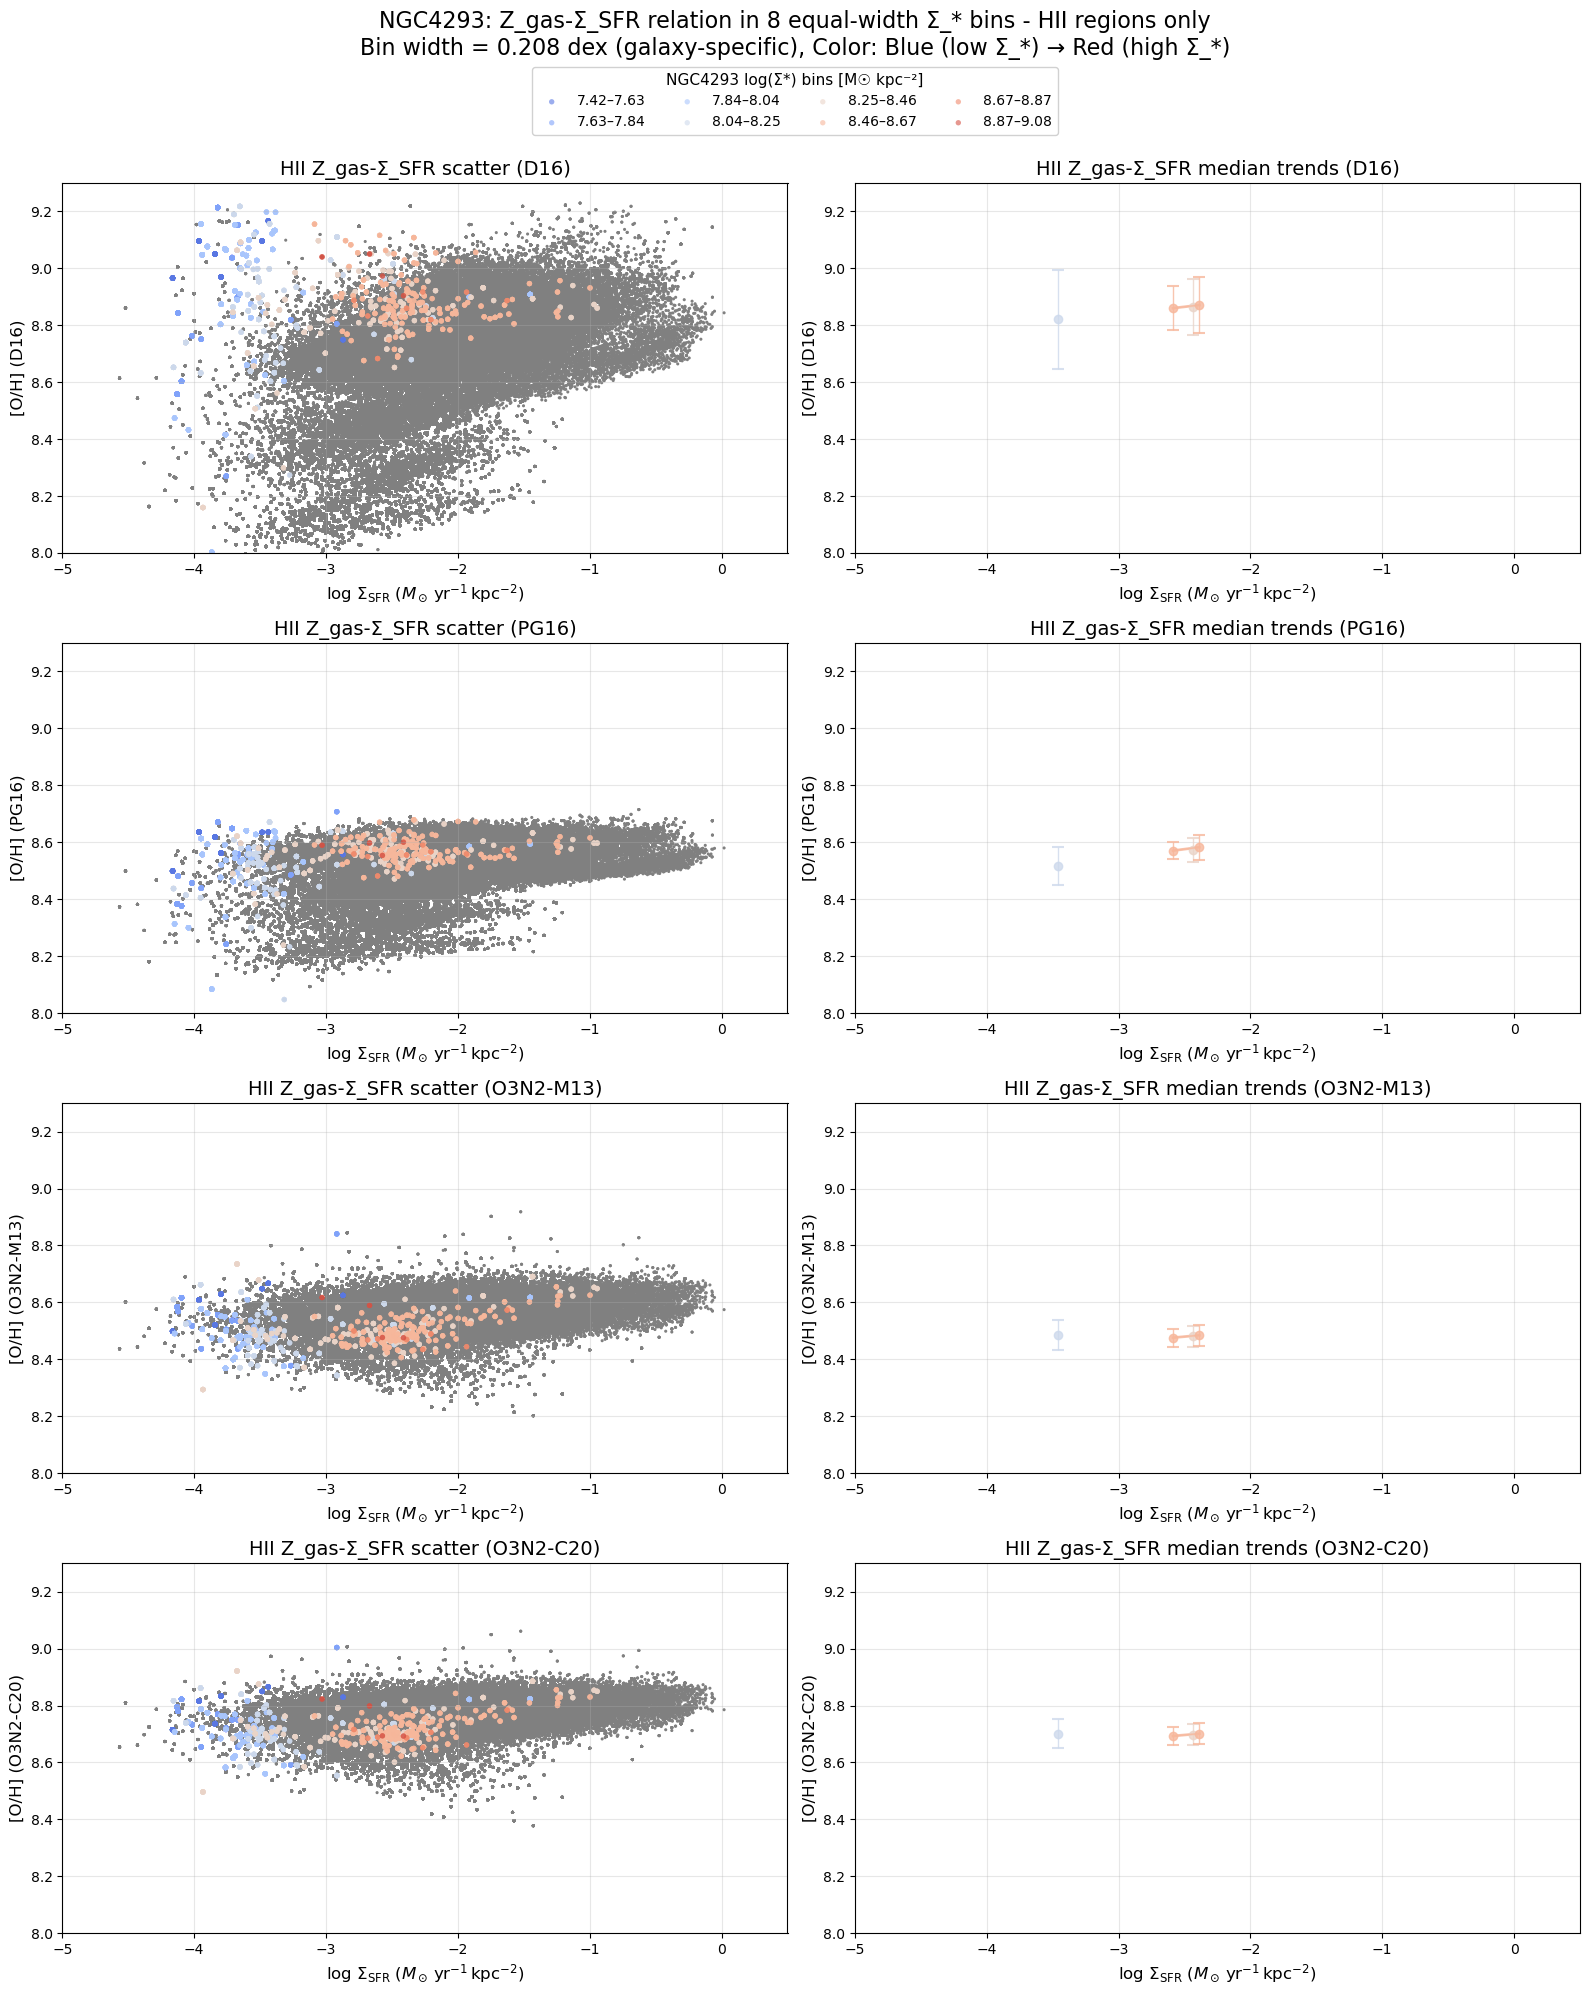


Successfully created 4x2 subplot figure for NGC4293
Binning summary:
  Number of bins: 8
  Bin width: 0.208 dex (equal width)
  Σ_* range: 7.419 to 9.082

Processing galaxy: NGC4298
Total HII pixels with all calibrations: 156350

NGC4298 Σ_* range:
  Min: 7.108
  Max: 9.347
  Range: 2.239

NGC4298 Bin width: 0.280

NGC4298 8 equal-width Σ_* bins:
  Bin edges: ['7.108', '7.388', '7.668', '7.948', '8.227', '8.507', '8.787', '9.067', '9.347']
  Bin 1: 7.11–7.39
  Bin 2: 7.39–7.67
  Bin 3: 7.67–7.95
  Bin 4: 7.95–8.23
  Bin 5: 8.23–8.51
  Bin 6: 8.51–8.79
  Bin 7: 8.79–9.07
  Bin 8: 9.07–9.35

NGC4298 Pixel counts per bin:
  Bin 1 (7.11–7.39): 3619 pixels (2.3%)
  Bin 2 (7.39–7.67): 23783 pixels (15.2%)
  Bin 3 (7.67–7.95): 58860 pixels (37.6%)
  Bin 4 (7.95–8.23): 46325 pixels (29.6%)
  Bin 5 (8.23–8.51): 17619 pixels (11.3%)
  Bin 6 (8.51–8.79): 4788 pixels (3.1%)
  Bin 7 (8.79–9.07): 1185 pixels (0.8%)
  Bin 8 (9.07–9.35): 171 pixels (0.1%)

Total pixels in bins: 156350 (should match 1

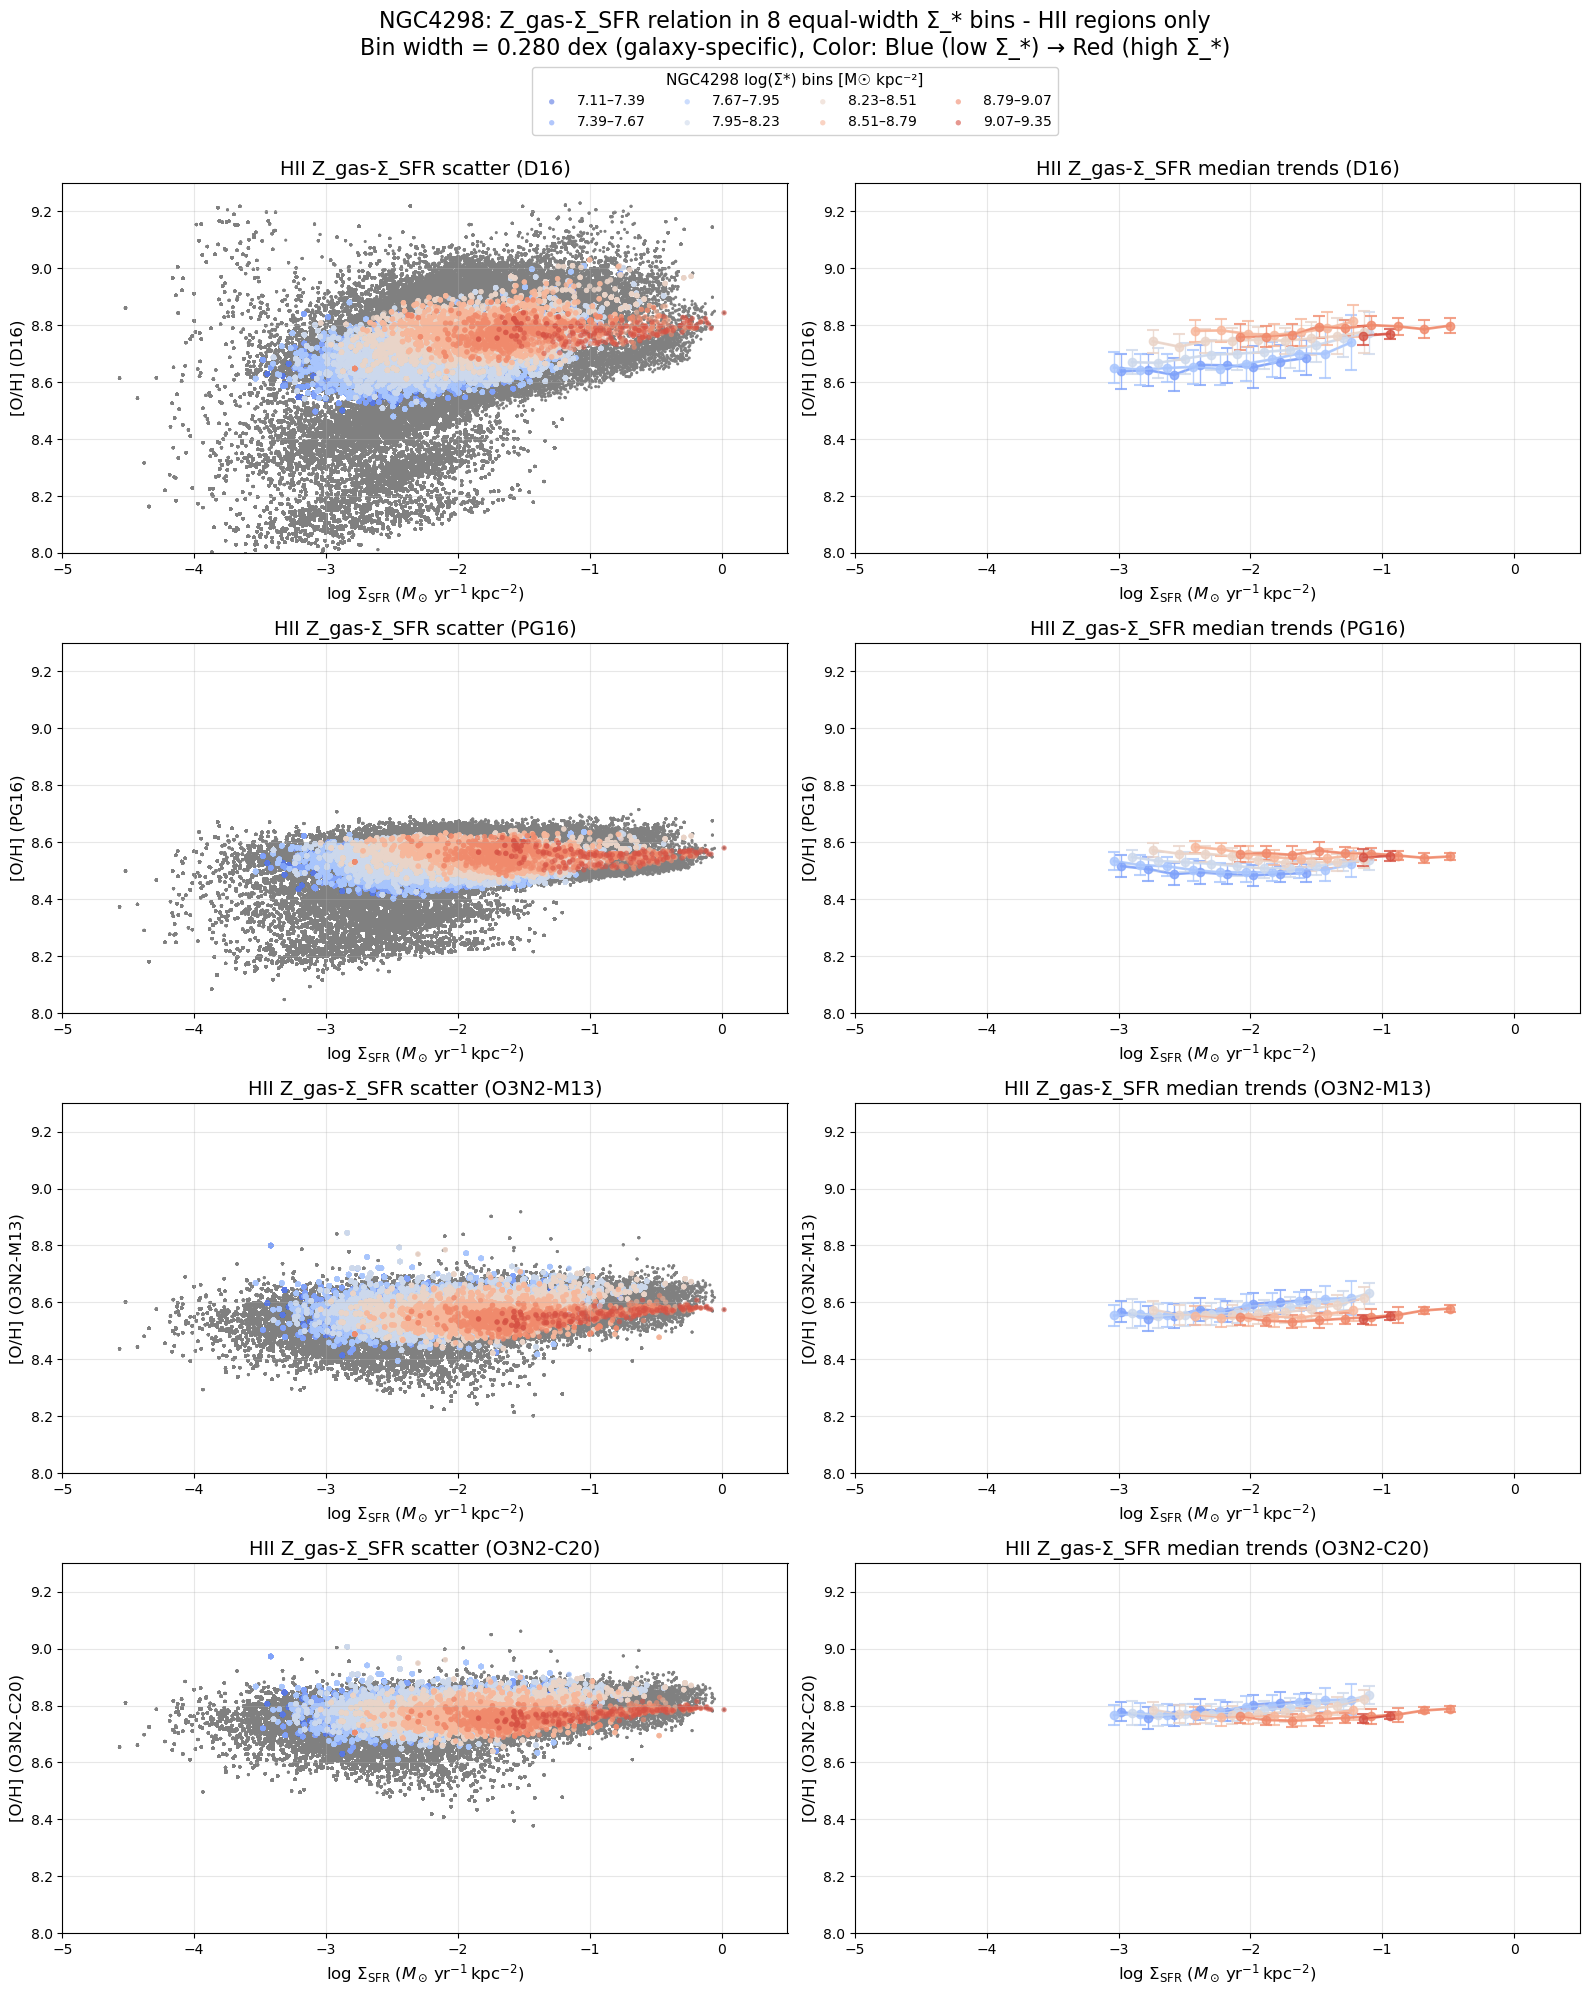


Successfully created 4x2 subplot figure for NGC4298
Binning summary:
  Number of bins: 8
  Bin width: 0.280 dex (equal width)
  Σ_* range: 7.108 to 9.347

Processing galaxy: NGC4330
Total HII pixels with all calibrations: 42566

NGC4330 Σ_* range:
  Min: 6.135
  Max: 8.400
  Range: 2.265

NGC4330 Bin width: 0.283

NGC4330 8 equal-width Σ_* bins:
  Bin edges: ['6.135', '6.418', '6.701', '6.984', '7.268', '7.551', '7.834', '8.117', '8.400']
  Bin 1: 6.13–6.42
  Bin 2: 6.42–6.70
  Bin 3: 6.70–6.98
  Bin 4: 6.98–7.27
  Bin 5: 7.27–7.55
  Bin 6: 7.55–7.83
  Bin 7: 7.83–8.12
  Bin 8: 8.12–8.40

NGC4330 Pixel counts per bin:
  Bin 1 (6.13–6.42): 140 pixels (0.3%)
  Bin 2 (6.42–6.70): 0 pixels (0.0%)
  Bin 3 (6.70–6.98): 2134 pixels (5.0%)
  Bin 4 (6.98–7.27): 9431 pixels (22.2%)
  Bin 5 (7.27–7.55): 15517 pixels (36.5%)
  Bin 6 (7.55–7.83): 11773 pixels (27.7%)
  Bin 7 (7.83–8.12): 3004 pixels (7.1%)
  Bin 8 (8.12–8.40): 567 pixels (1.3%)

Total pixels in bins: 42566 (should match 42566)

Pr

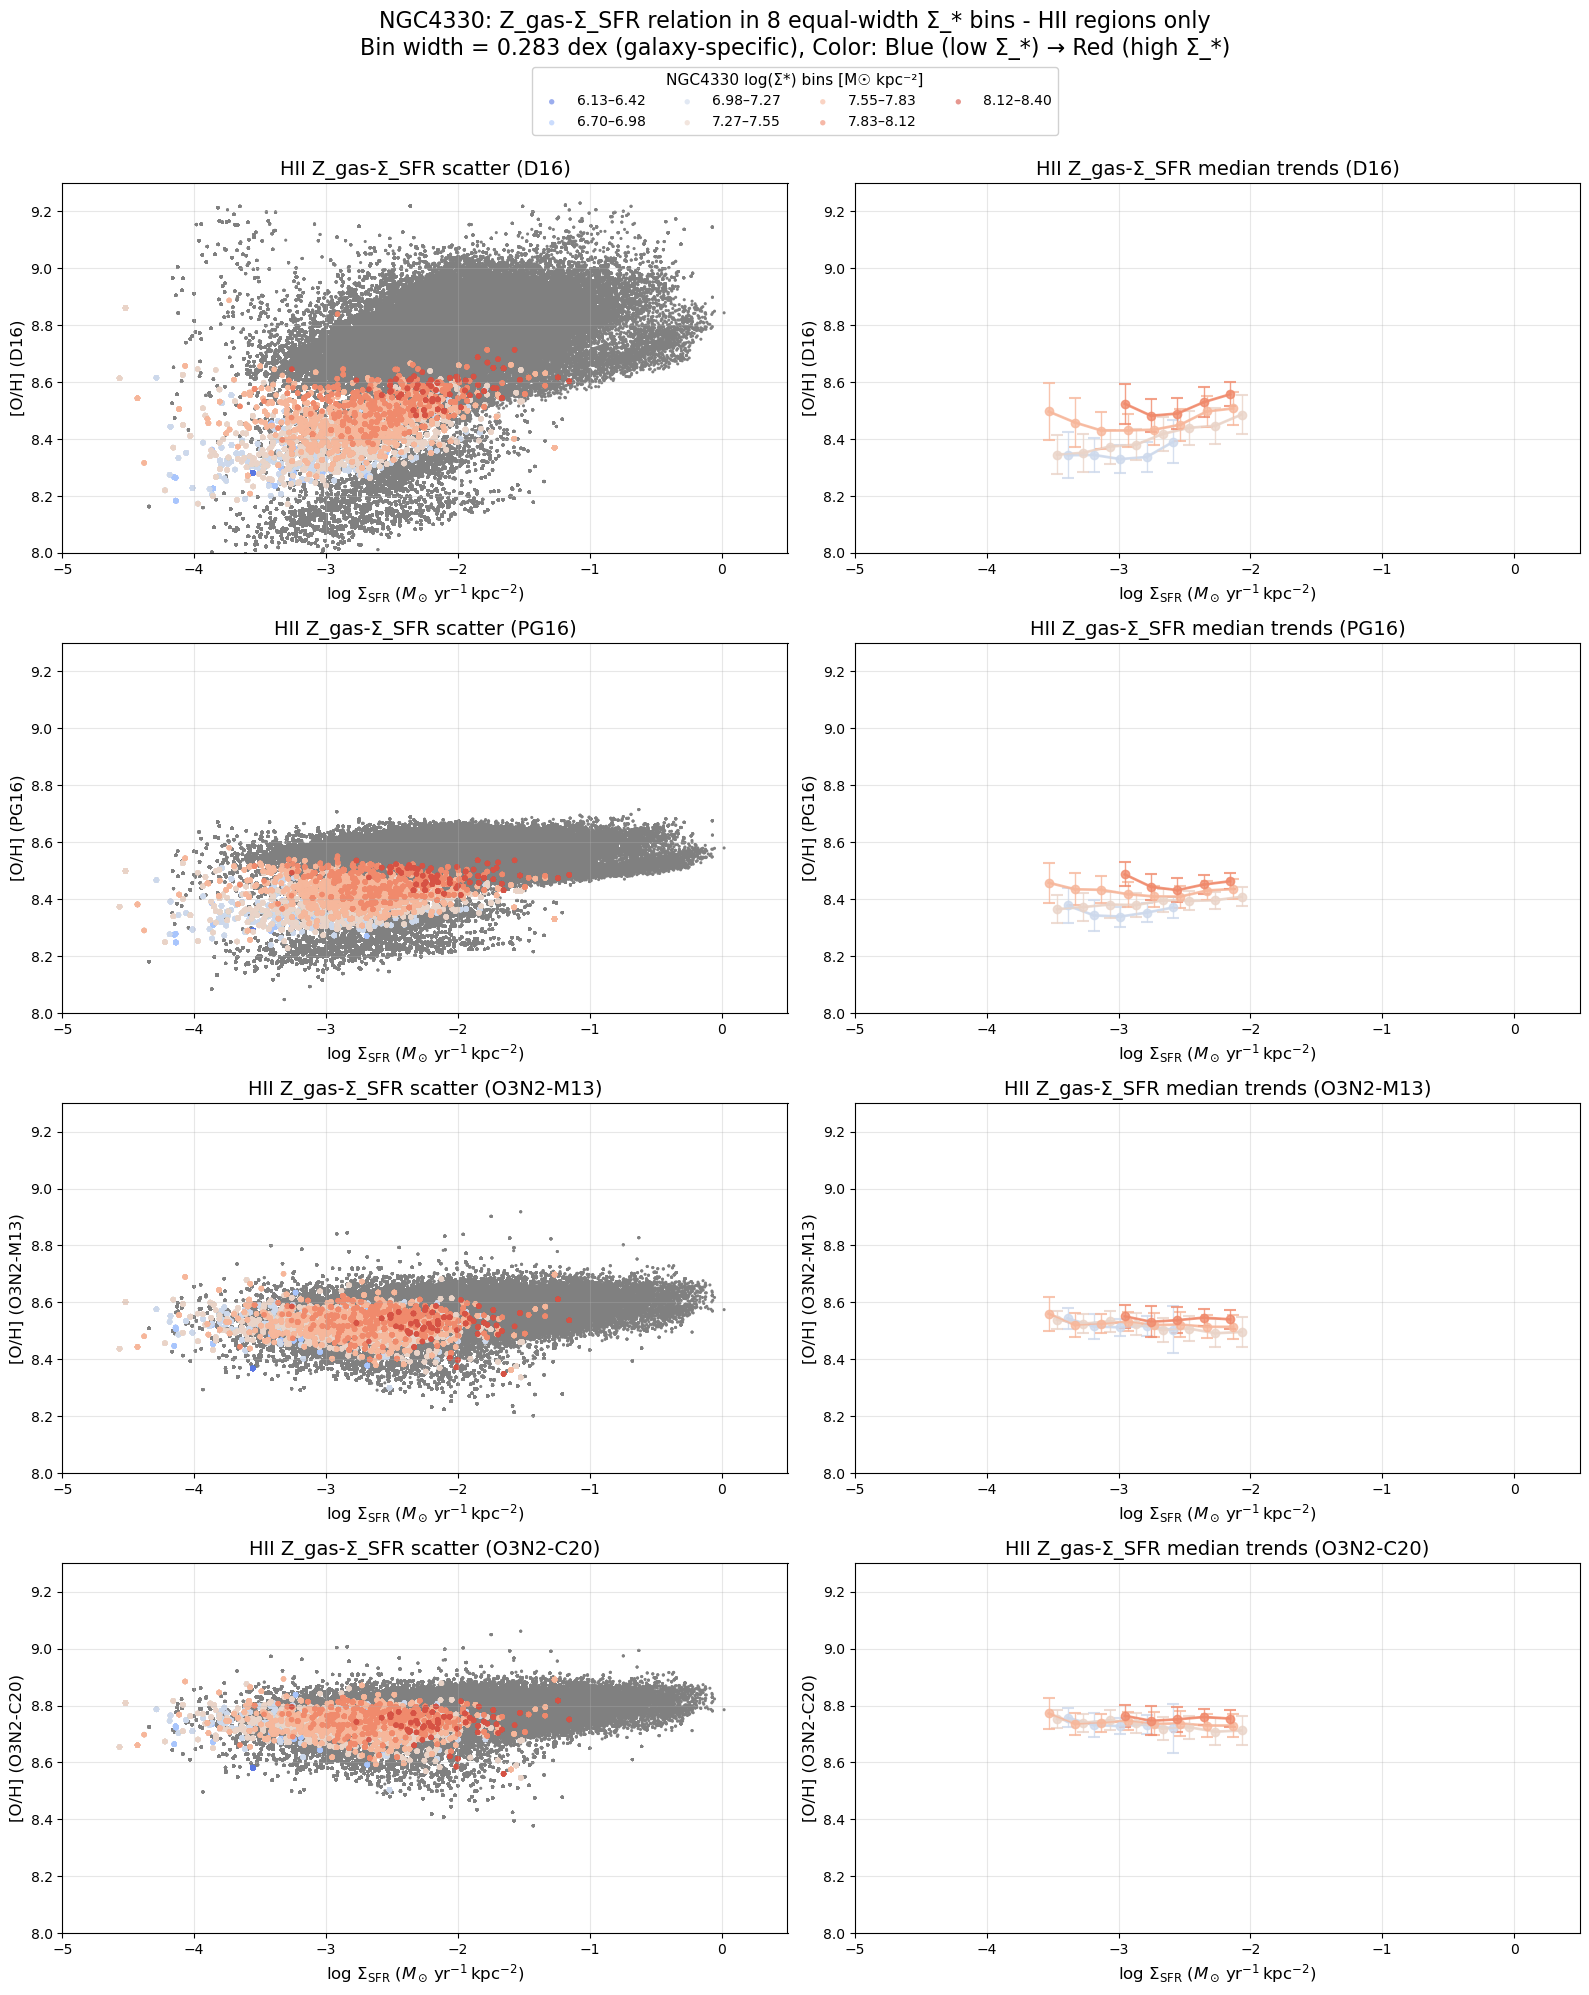


Successfully created 4x2 subplot figure for NGC4330
Binning summary:
  Number of bins: 8
  Bin width: 0.283 dex (equal width)
  Σ_* range: 6.135 to 8.400

Skipping NGC4383 (excluded from analysis)

Processing galaxy: NGC4396
Total HII pixels with all calibrations: 81728

NGC4396 Σ_* range:
  Min: 6.241
  Max: 9.241
  Range: 3.000

NGC4396 Bin width: 0.375

NGC4396 8 equal-width Σ_* bins:
  Bin edges: ['6.241', '6.616', '6.991', '7.366', '7.741', '8.116', '8.491', '8.866', '9.241']
  Bin 1: 6.24–6.62
  Bin 2: 6.62–6.99
  Bin 3: 6.99–7.37
  Bin 4: 7.37–7.74
  Bin 5: 7.74–8.12
  Bin 6: 8.12–8.49
  Bin 7: 8.49–8.87
  Bin 8: 8.87–9.24

NGC4396 Pixel counts per bin:
  Bin 1 (6.24–6.62): 2310 pixels (2.8%)
  Bin 2 (6.62–6.99): 27335 pixels (33.4%)
  Bin 3 (6.99–7.37): 36720 pixels (44.9%)
  Bin 4 (7.37–7.74): 12994 pixels (15.9%)
  Bin 5 (7.74–8.12): 2355 pixels (2.9%)
  Bin 6 (8.12–8.49): 11 pixels (0.0%)
  Bin 7 (8.49–8.87): 2 pixels (0.0%)
  Bin 8 (8.87–9.24): 1 pixels (0.0%)

Total pixel

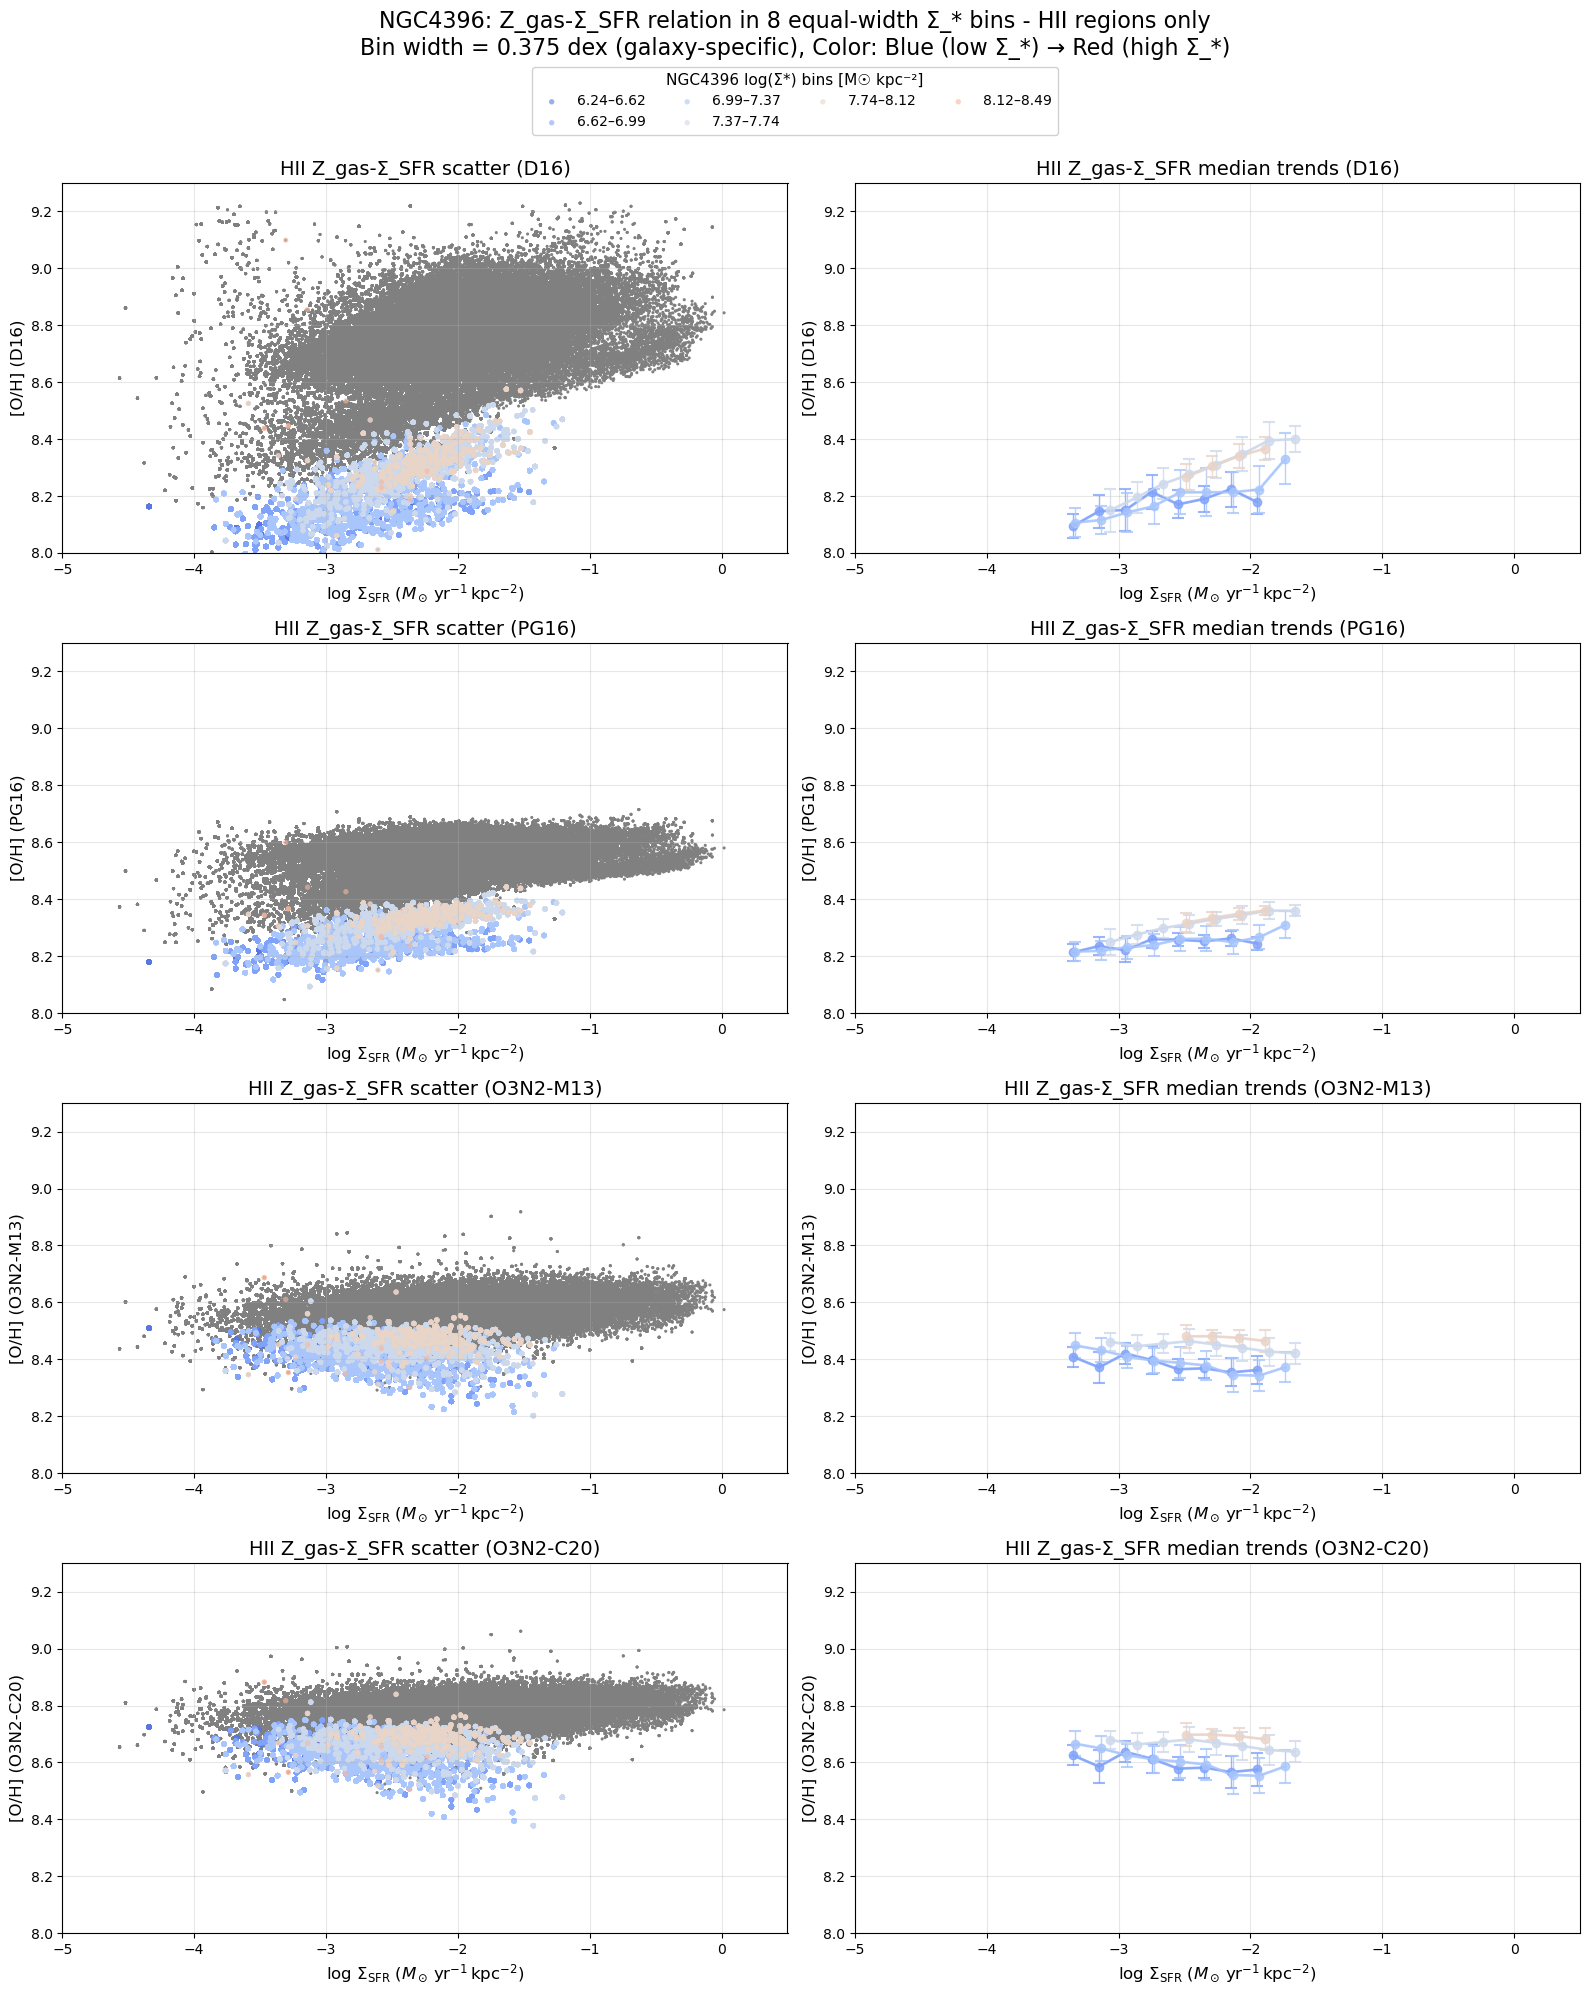


Successfully created 4x2 subplot figure for NGC4396
Binning summary:
  Number of bins: 8
  Bin width: 0.375 dex (equal width)
  Σ_* range: 6.241 to 9.241

Processing galaxy: NGC4419
Total HII pixels with all calibrations: 6886

NGC4419 Σ_* range:
  Min: 7.259
  Max: 9.311
  Range: 2.052

NGC4419 Bin width: 0.256

NGC4419 8 equal-width Σ_* bins:
  Bin edges: ['7.259', '7.515', '7.772', '8.028', '8.285', '8.541', '8.798', '9.054', '9.311']
  Bin 1: 7.26–7.52
  Bin 2: 7.52–7.77
  Bin 3: 7.77–8.03
  Bin 4: 8.03–8.28
  Bin 5: 8.28–8.54
  Bin 6: 8.54–8.80
  Bin 7: 8.80–9.05
  Bin 8: 9.05–9.31

NGC4419 Pixel counts per bin:
  Bin 1 (7.26–7.52): 543 pixels (7.9%)
  Bin 2 (7.52–7.77): 167 pixels (2.4%)
  Bin 3 (7.77–8.03): 88 pixels (1.3%)
  Bin 4 (8.03–8.28): 1025 pixels (14.9%)
  Bin 5 (8.28–8.54): 3215 pixels (46.7%)
  Bin 6 (8.54–8.80): 1526 pixels (22.2%)
  Bin 7 (8.80–9.05): 263 pixels (3.8%)
  Bin 8 (9.05–9.31): 59 pixels (0.9%)

Total pixels in bins: 6886 (should match 6886)

Processin

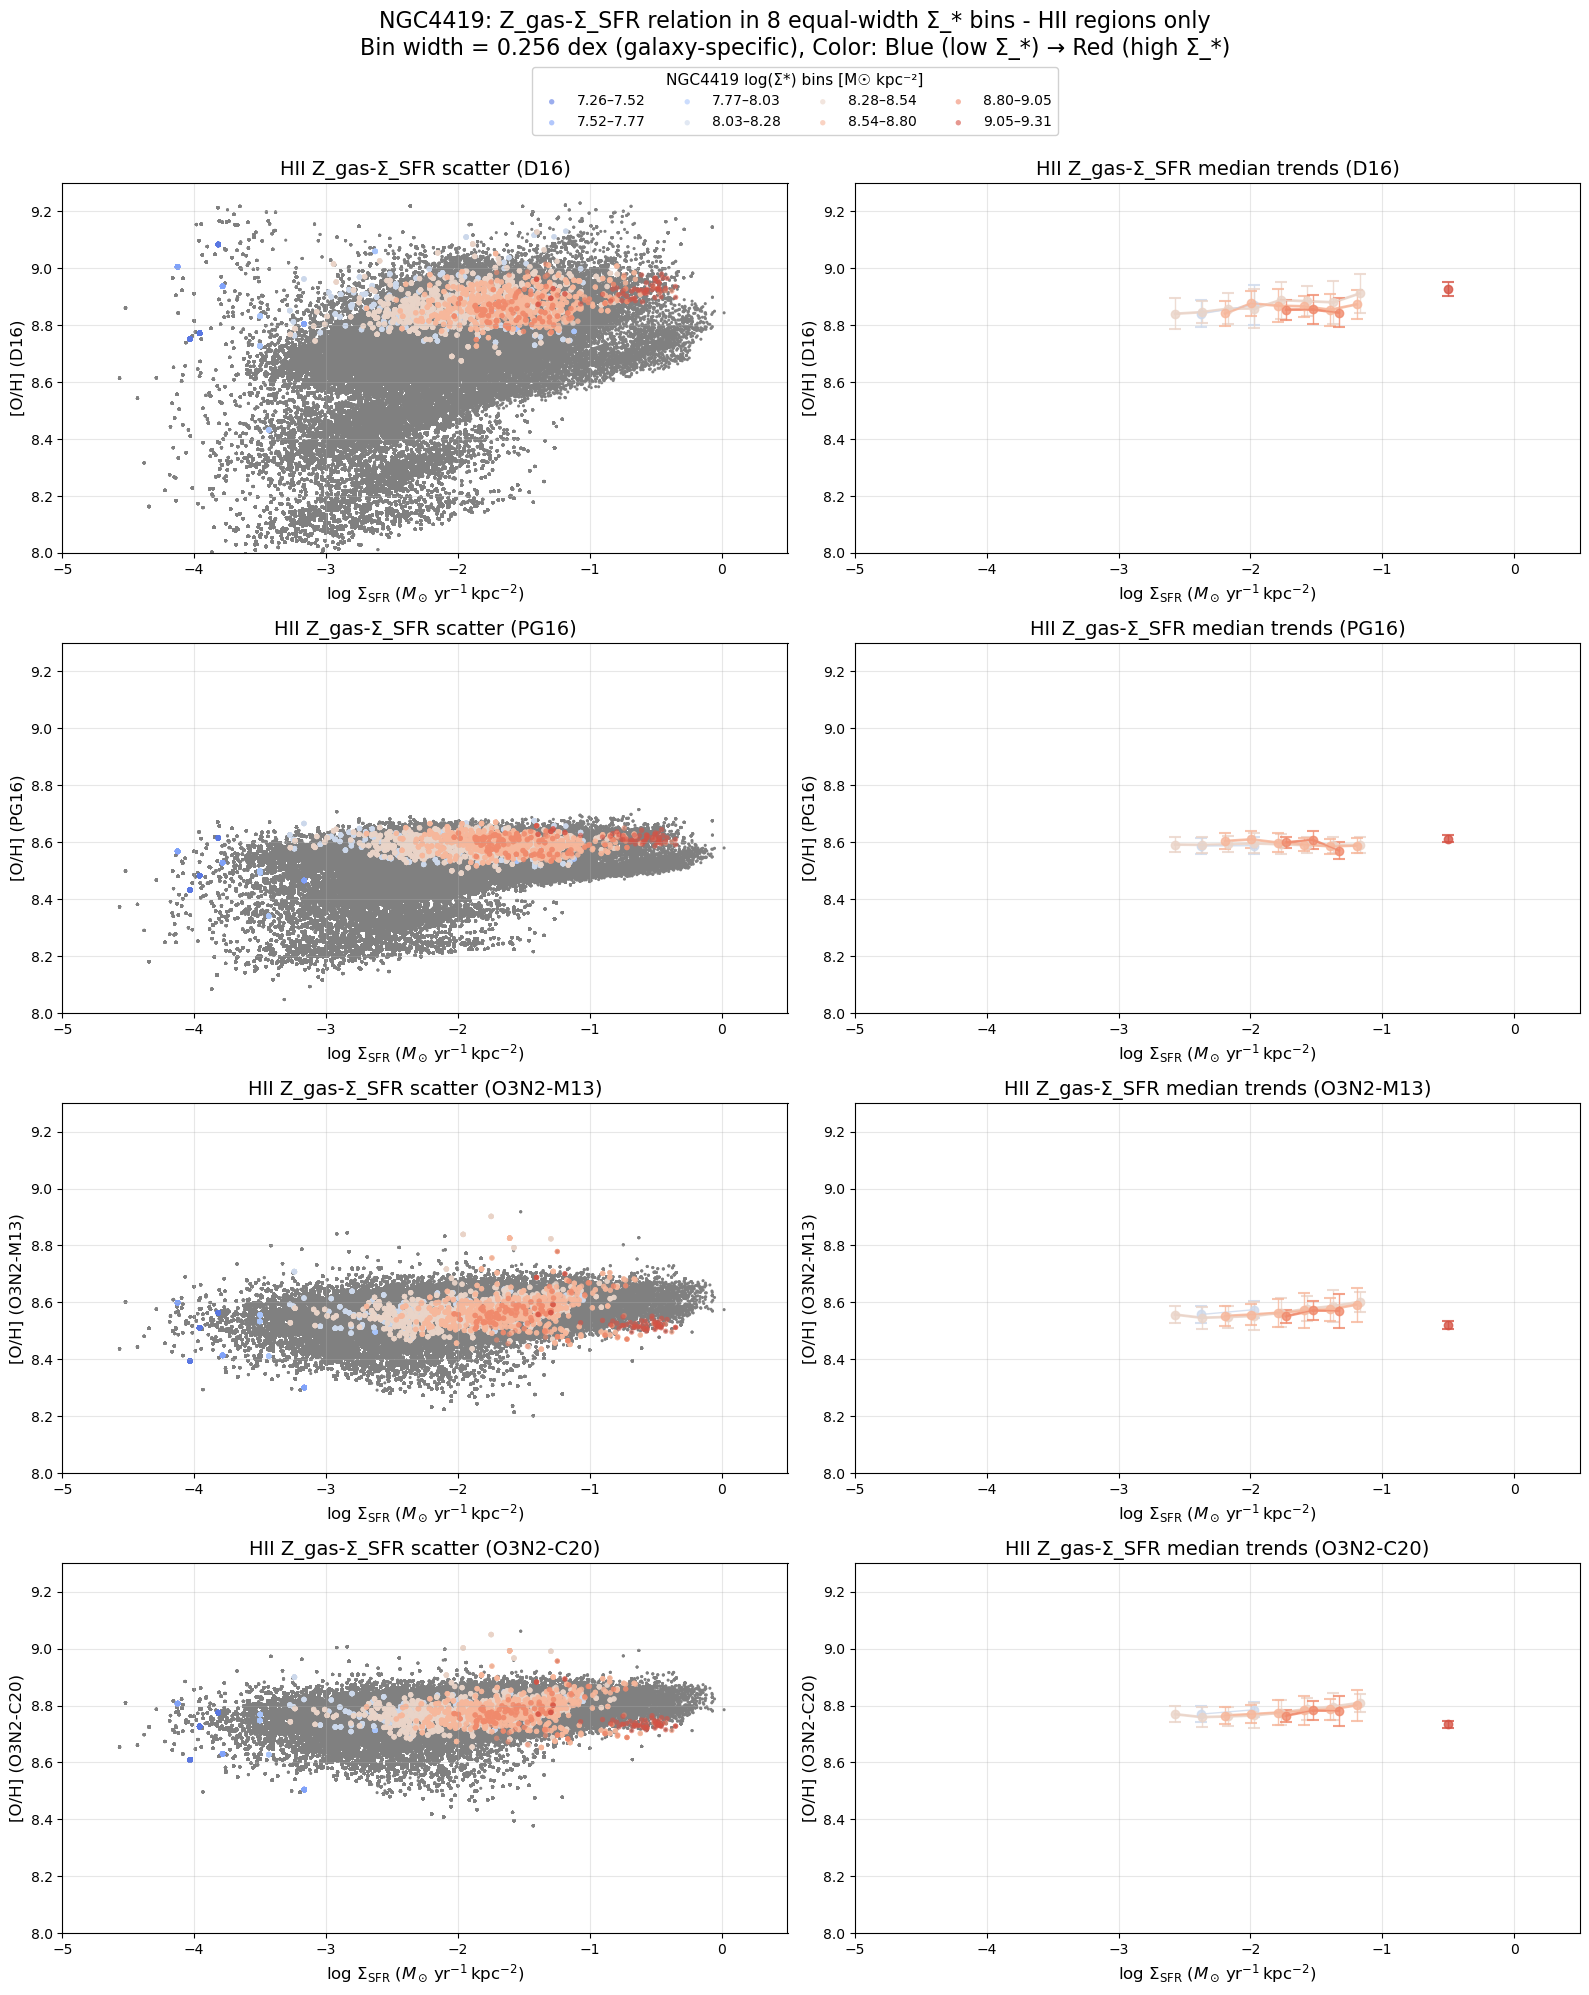


Successfully created 4x2 subplot figure for NGC4419
Binning summary:
  Number of bins: 8
  Bin width: 0.256 dex (equal width)
  Σ_* range: 7.259 to 9.311

Processing galaxy: NGC4457
Total HII pixels with all calibrations: 6000

NGC4457 Σ_* range:
  Min: 8.059
  Max: 9.508
  Range: 1.449

NGC4457 Bin width: 0.181

NGC4457 8 equal-width Σ_* bins:
  Bin edges: ['8.059', '8.240', '8.421', '8.602', '8.783', '8.965', '9.146', '9.327', '9.508']
  Bin 1: 8.06–8.24
  Bin 2: 8.24–8.42
  Bin 3: 8.42–8.60
  Bin 4: 8.60–8.78
  Bin 5: 8.78–8.96
  Bin 6: 8.96–9.15
  Bin 7: 9.15–9.33
  Bin 8: 9.33–9.51

NGC4457 Pixel counts per bin:
  Bin 1 (8.06–8.24): 156 pixels (2.6%)
  Bin 2 (8.24–8.42): 979 pixels (16.3%)
  Bin 3 (8.42–8.60): 2023 pixels (33.7%)
  Bin 4 (8.60–8.78): 1881 pixels (31.4%)
  Bin 5 (8.78–8.96): 791 pixels (13.2%)
  Bin 6 (8.96–9.15): 132 pixels (2.2%)
  Bin 7 (9.15–9.33): 36 pixels (0.6%)
  Bin 8 (9.33–9.51): 2 pixels (0.0%)

Total pixels in bins: 6000 (should match 6000)

Processing

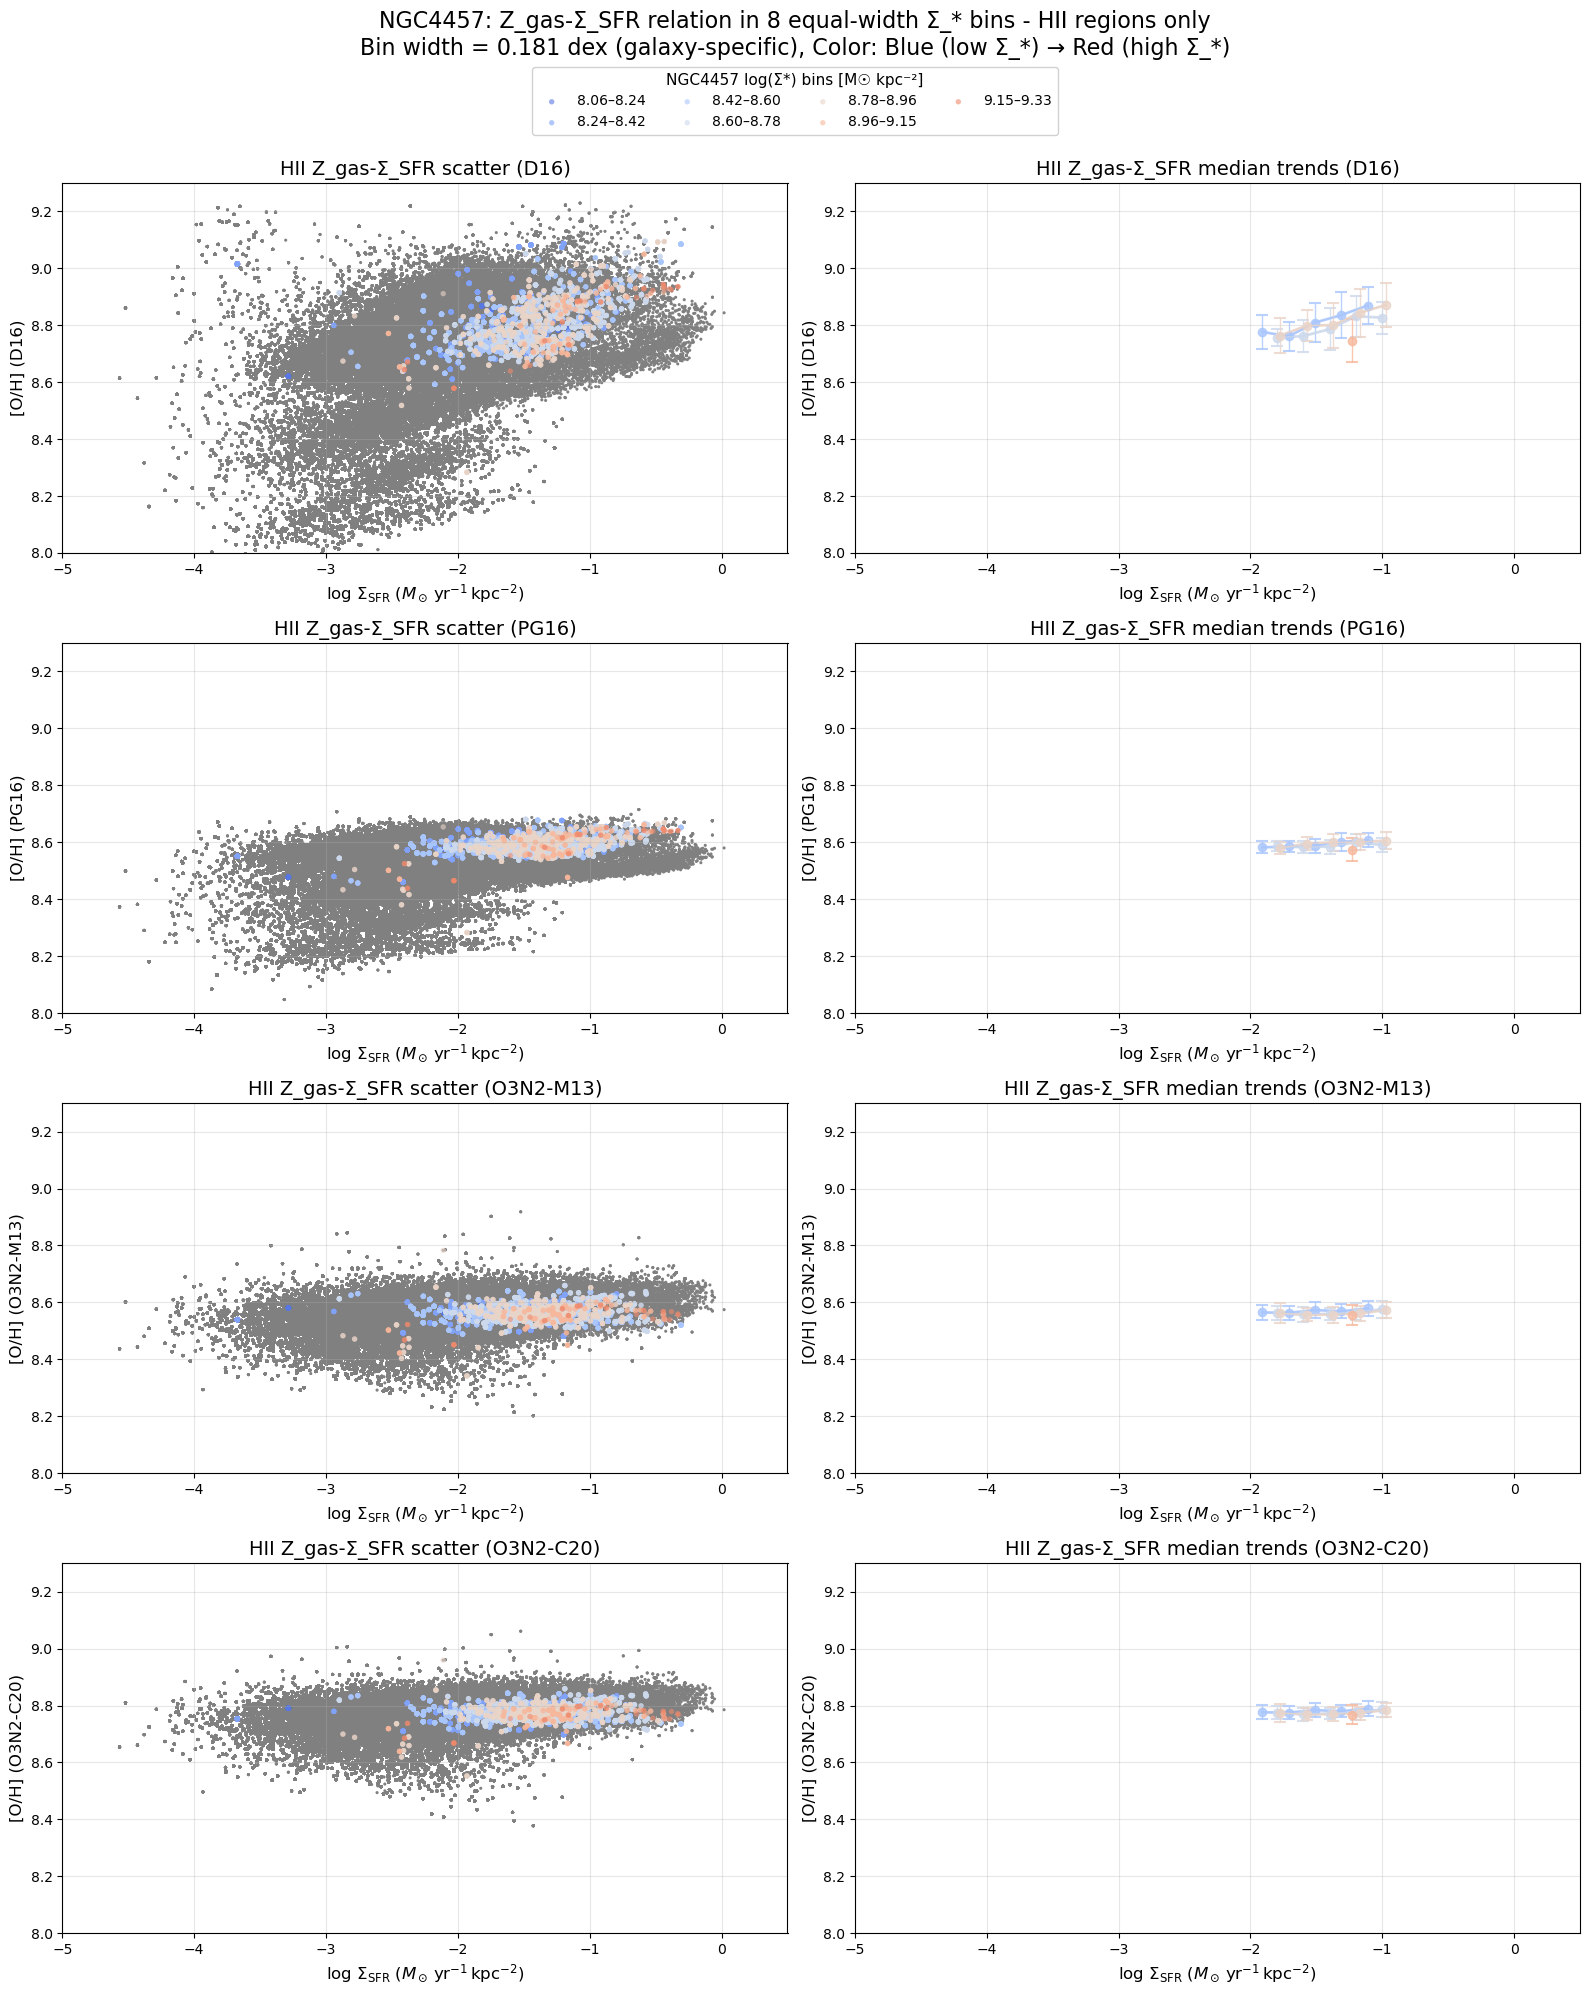


Successfully created 4x2 subplot figure for NGC4457
Binning summary:
  Number of bins: 8
  Bin width: 0.181 dex (equal width)
  Σ_* range: 8.059 to 9.508

Processing galaxy: NGC4501
Total HII pixels with all calibrations: 260854

NGC4501 Σ_* range:
  Min: 7.128
  Max: 9.407
  Range: 2.279

NGC4501 Bin width: 0.285

NGC4501 8 equal-width Σ_* bins:
  Bin edges: ['7.128', '7.413', '7.698', '7.983', '8.268', '8.552', '8.837', '9.122', '9.407']
  Bin 1: 7.13–7.41
  Bin 2: 7.41–7.70
  Bin 3: 7.70–7.98
  Bin 4: 7.98–8.27
  Bin 5: 8.27–8.55
  Bin 6: 8.55–8.84
  Bin 7: 8.84–9.12
  Bin 8: 9.12–9.41

NGC4501 Pixel counts per bin:
  Bin 1 (7.13–7.41): 504 pixels (0.2%)
  Bin 2 (7.41–7.70): 10566 pixels (4.1%)
  Bin 3 (7.70–7.98): 54197 pixels (20.8%)
  Bin 4 (7.98–8.27): 78684 pixels (30.2%)
  Bin 5 (8.27–8.55): 62744 pixels (24.1%)
  Bin 6 (8.55–8.84): 44453 pixels (17.0%)
  Bin 7 (8.84–9.12): 9466 pixels (3.6%)
  Bin 8 (9.12–9.41): 240 pixels (0.1%)

Total pixels in bins: 260854 (should match 2

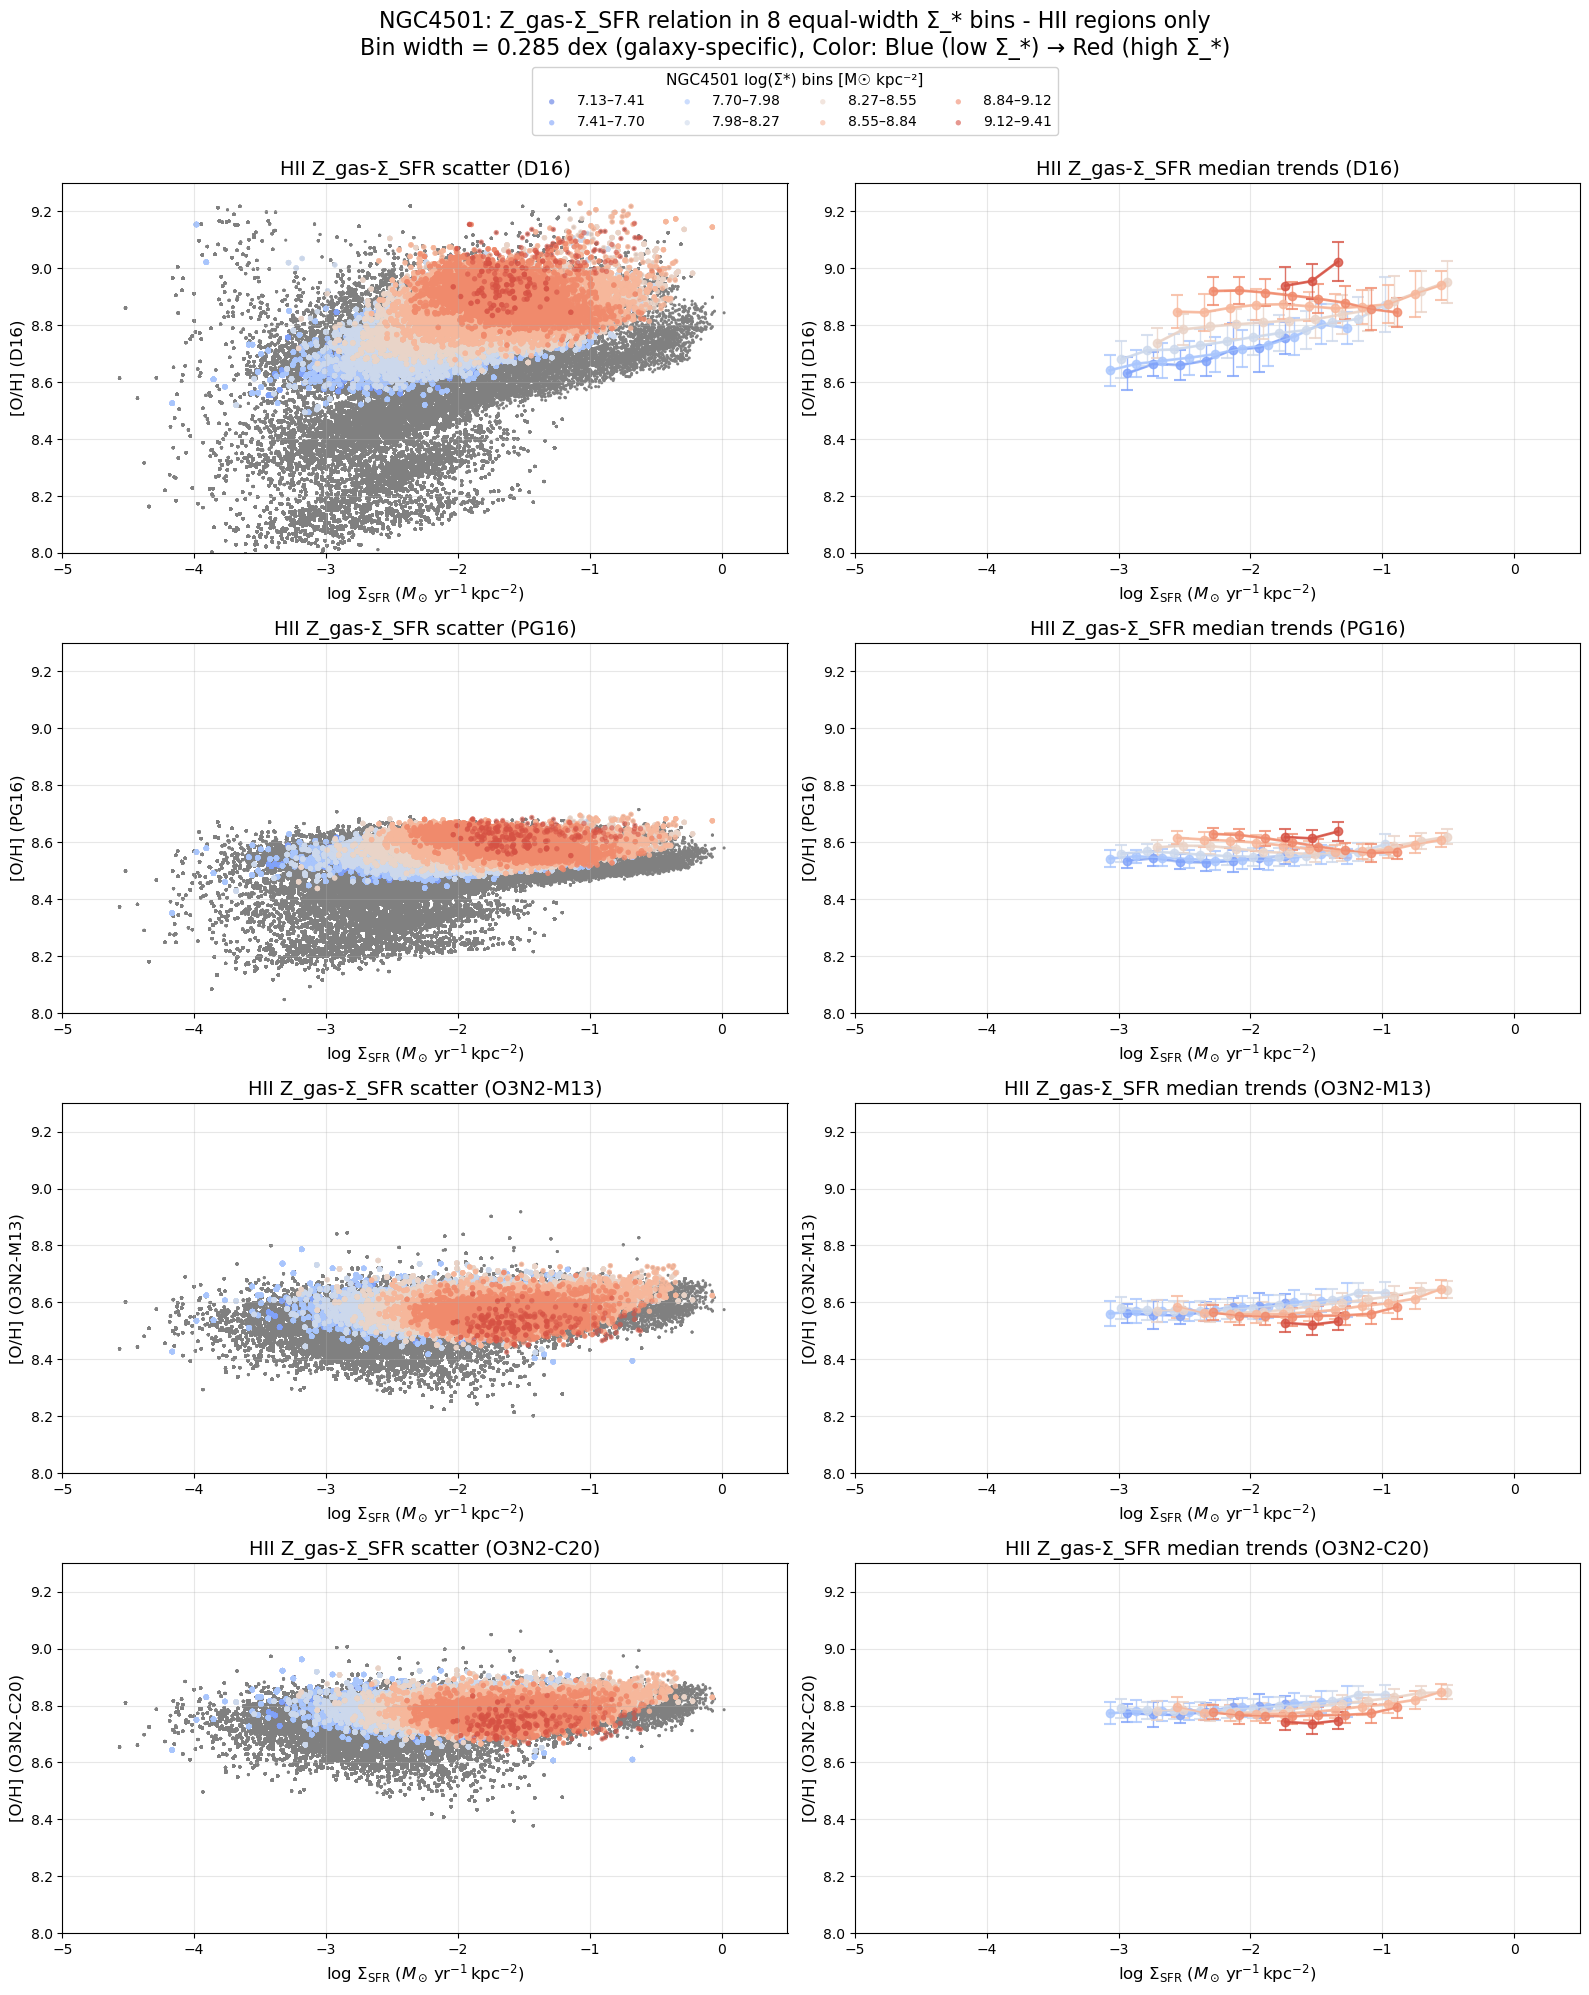


Successfully created 4x2 subplot figure for NGC4501
Binning summary:
  Number of bins: 8
  Bin width: 0.285 dex (equal width)
  Σ_* range: 7.128 to 9.407

Processing galaxy: NGC4522
Total HII pixels with all calibrations: 39354

NGC4522 Σ_* range:
  Min: 5.986
  Max: 8.570
  Range: 2.585

NGC4522 Bin width: 0.323

NGC4522 8 equal-width Σ_* bins:
  Bin edges: ['5.986', '6.309', '6.632', '6.955', '7.278', '7.601', '7.924', '8.247', '8.570']
  Bin 1: 5.99–6.31
  Bin 2: 6.31–6.63
  Bin 3: 6.63–6.95
  Bin 4: 6.95–7.28
  Bin 5: 7.28–7.60
  Bin 6: 7.60–7.92
  Bin 7: 7.92–8.25
  Bin 8: 8.25–8.57

NGC4522 Pixel counts per bin:
  Bin 1 (5.99–6.31): 325 pixels (0.8%)
  Bin 2 (6.31–6.63): 2397 pixels (6.1%)
  Bin 3 (6.63–6.95): 7013 pixels (17.8%)
  Bin 4 (6.95–7.28): 9439 pixels (24.0%)
  Bin 5 (7.28–7.60): 11264 pixels (28.6%)
  Bin 6 (7.60–7.92): 7064 pixels (17.9%)
  Bin 7 (7.92–8.25): 1797 pixels (4.6%)
  Bin 8 (8.25–8.57): 55 pixels (0.1%)

Total pixels in bins: 39354 (should match 39354)



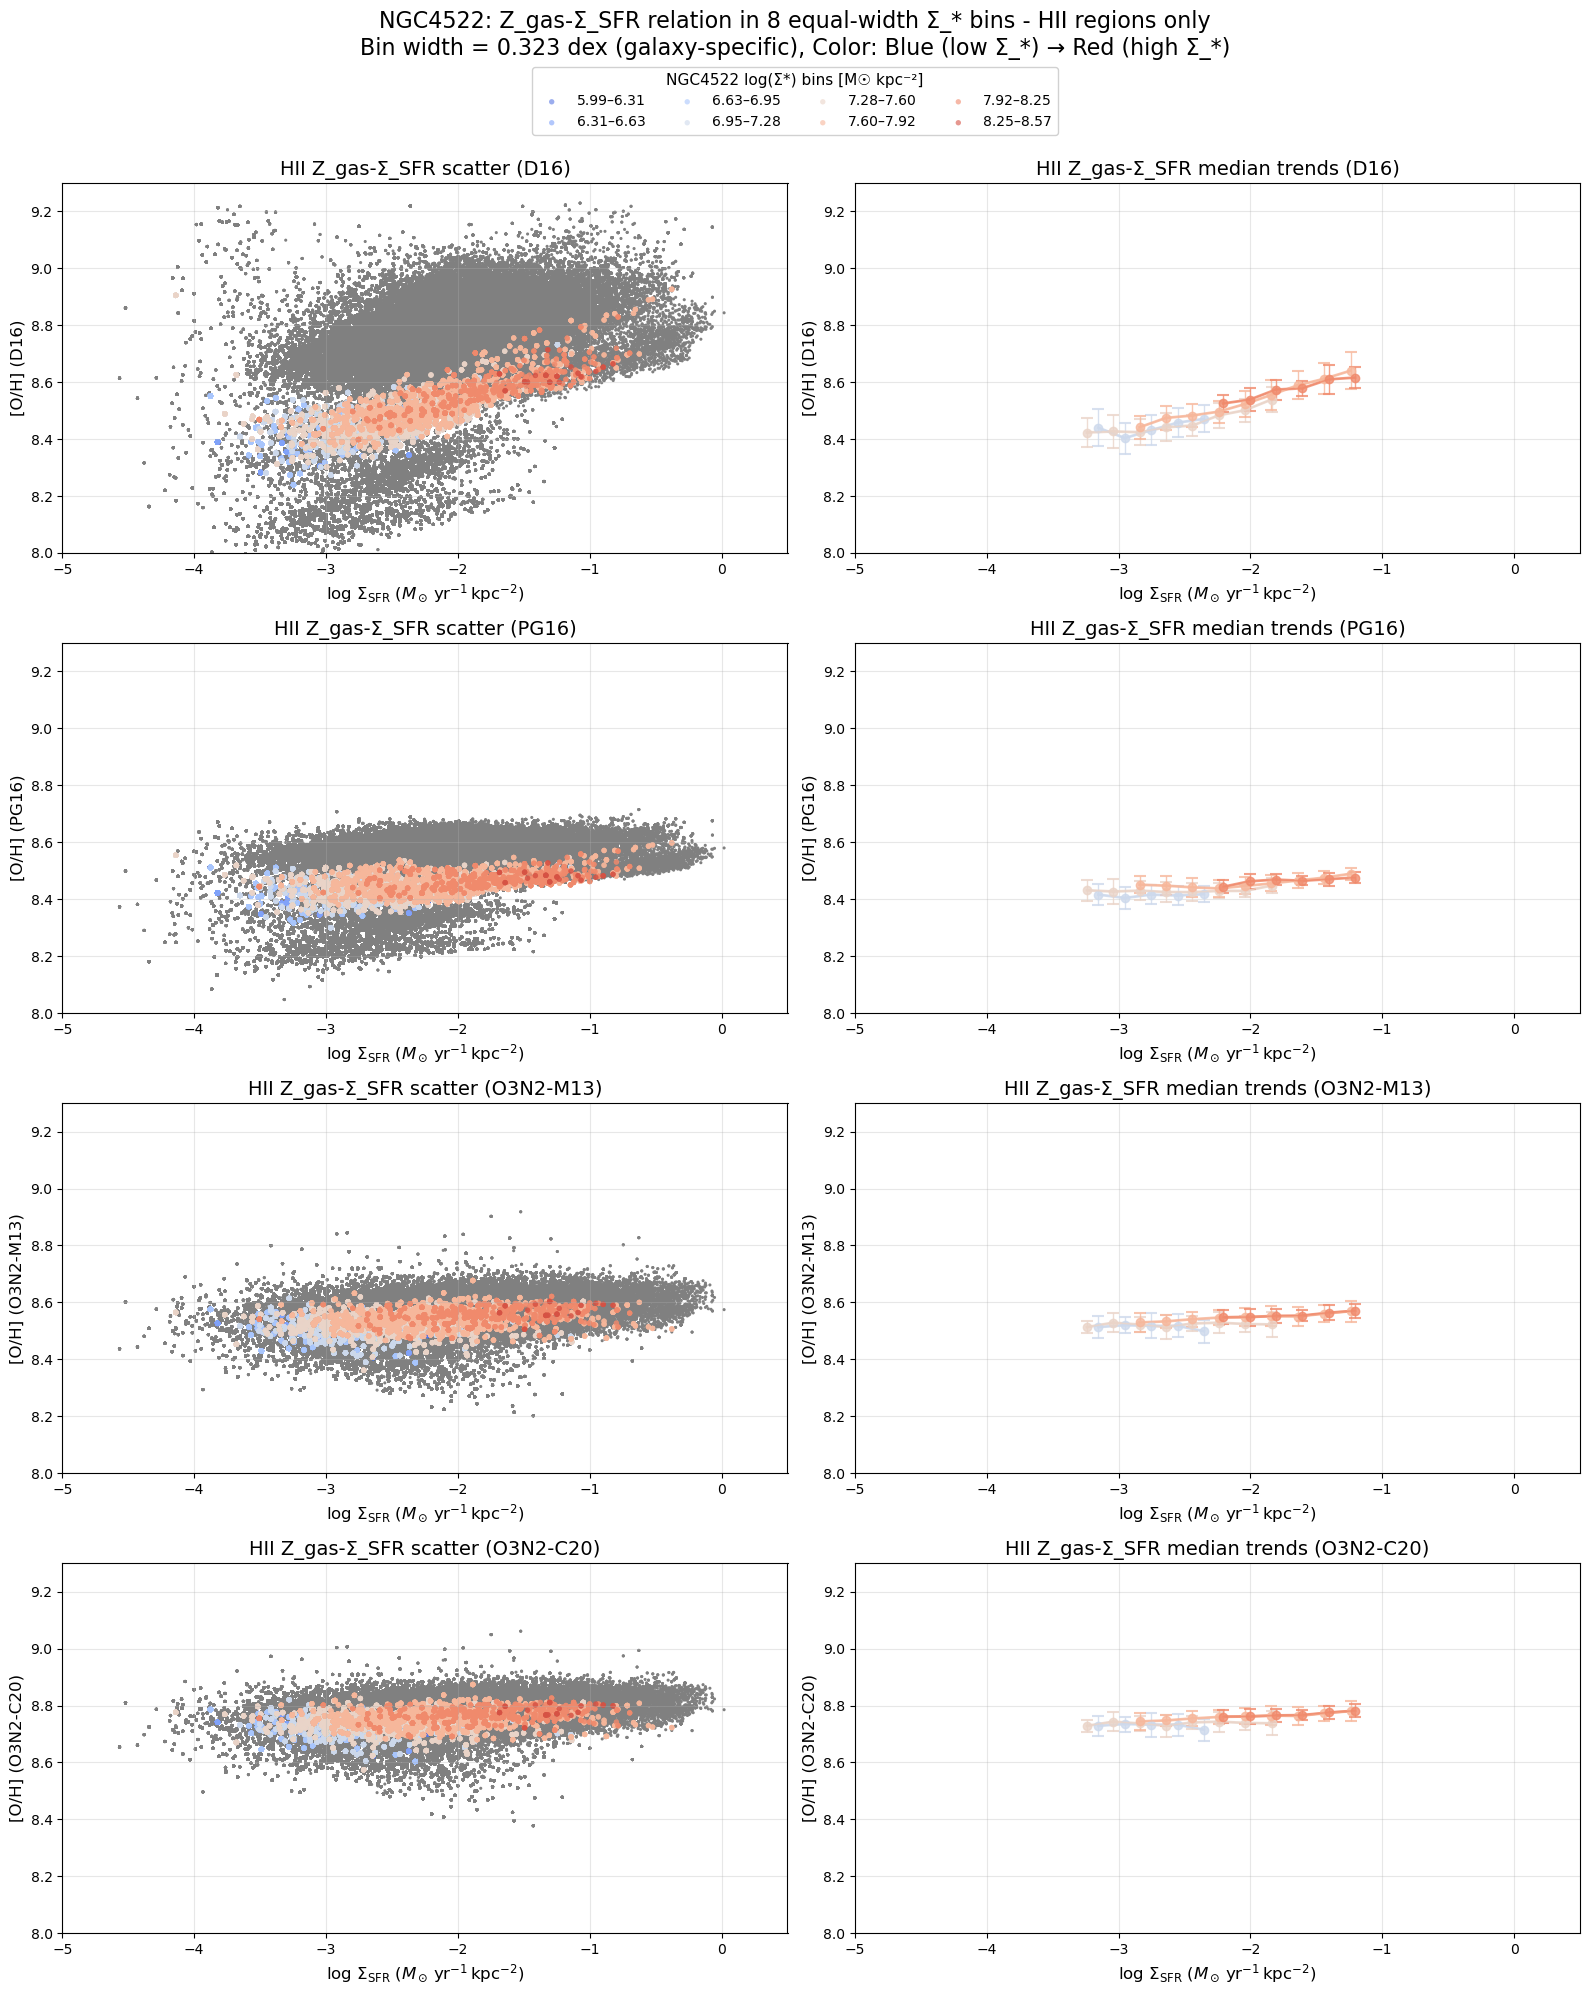


Successfully created 4x2 subplot figure for NGC4522
Binning summary:
  Number of bins: 8
  Bin width: 0.323 dex (equal width)
  Σ_* range: 5.986 to 8.570

Processing galaxy: NGC4694
Total HII pixels with all calibrations: 2585

NGC4694 Σ_* range:
  Min: 7.849
  Max: 9.356
  Range: 1.506

NGC4694 Bin width: 0.188

NGC4694 8 equal-width Σ_* bins:
  Bin edges: ['7.849', '8.038', '8.226', '8.414', '8.603', '8.791', '8.979', '9.167', '9.356']
  Bin 1: 7.85–8.04
  Bin 2: 8.04–8.23
  Bin 3: 8.23–8.41
  Bin 4: 8.41–8.60
  Bin 5: 8.60–8.79
  Bin 6: 8.79–8.98
  Bin 7: 8.98–9.17
  Bin 8: 9.17–9.36

NGC4694 Pixel counts per bin:
  Bin 1 (7.85–8.04): 42 pixels (1.6%)
  Bin 2 (8.04–8.23): 84 pixels (3.2%)
  Bin 3 (8.23–8.41): 201 pixels (7.8%)
  Bin 4 (8.41–8.60): 481 pixels (18.6%)
  Bin 5 (8.60–8.79): 631 pixels (24.4%)
  Bin 6 (8.79–8.98): 670 pixels (25.9%)
  Bin 7 (8.98–9.17): 411 pixels (15.9%)
  Bin 8 (9.17–9.36): 65 pixels (2.5%)

Total pixels in bins: 2585 (should match 2585)

Processing D

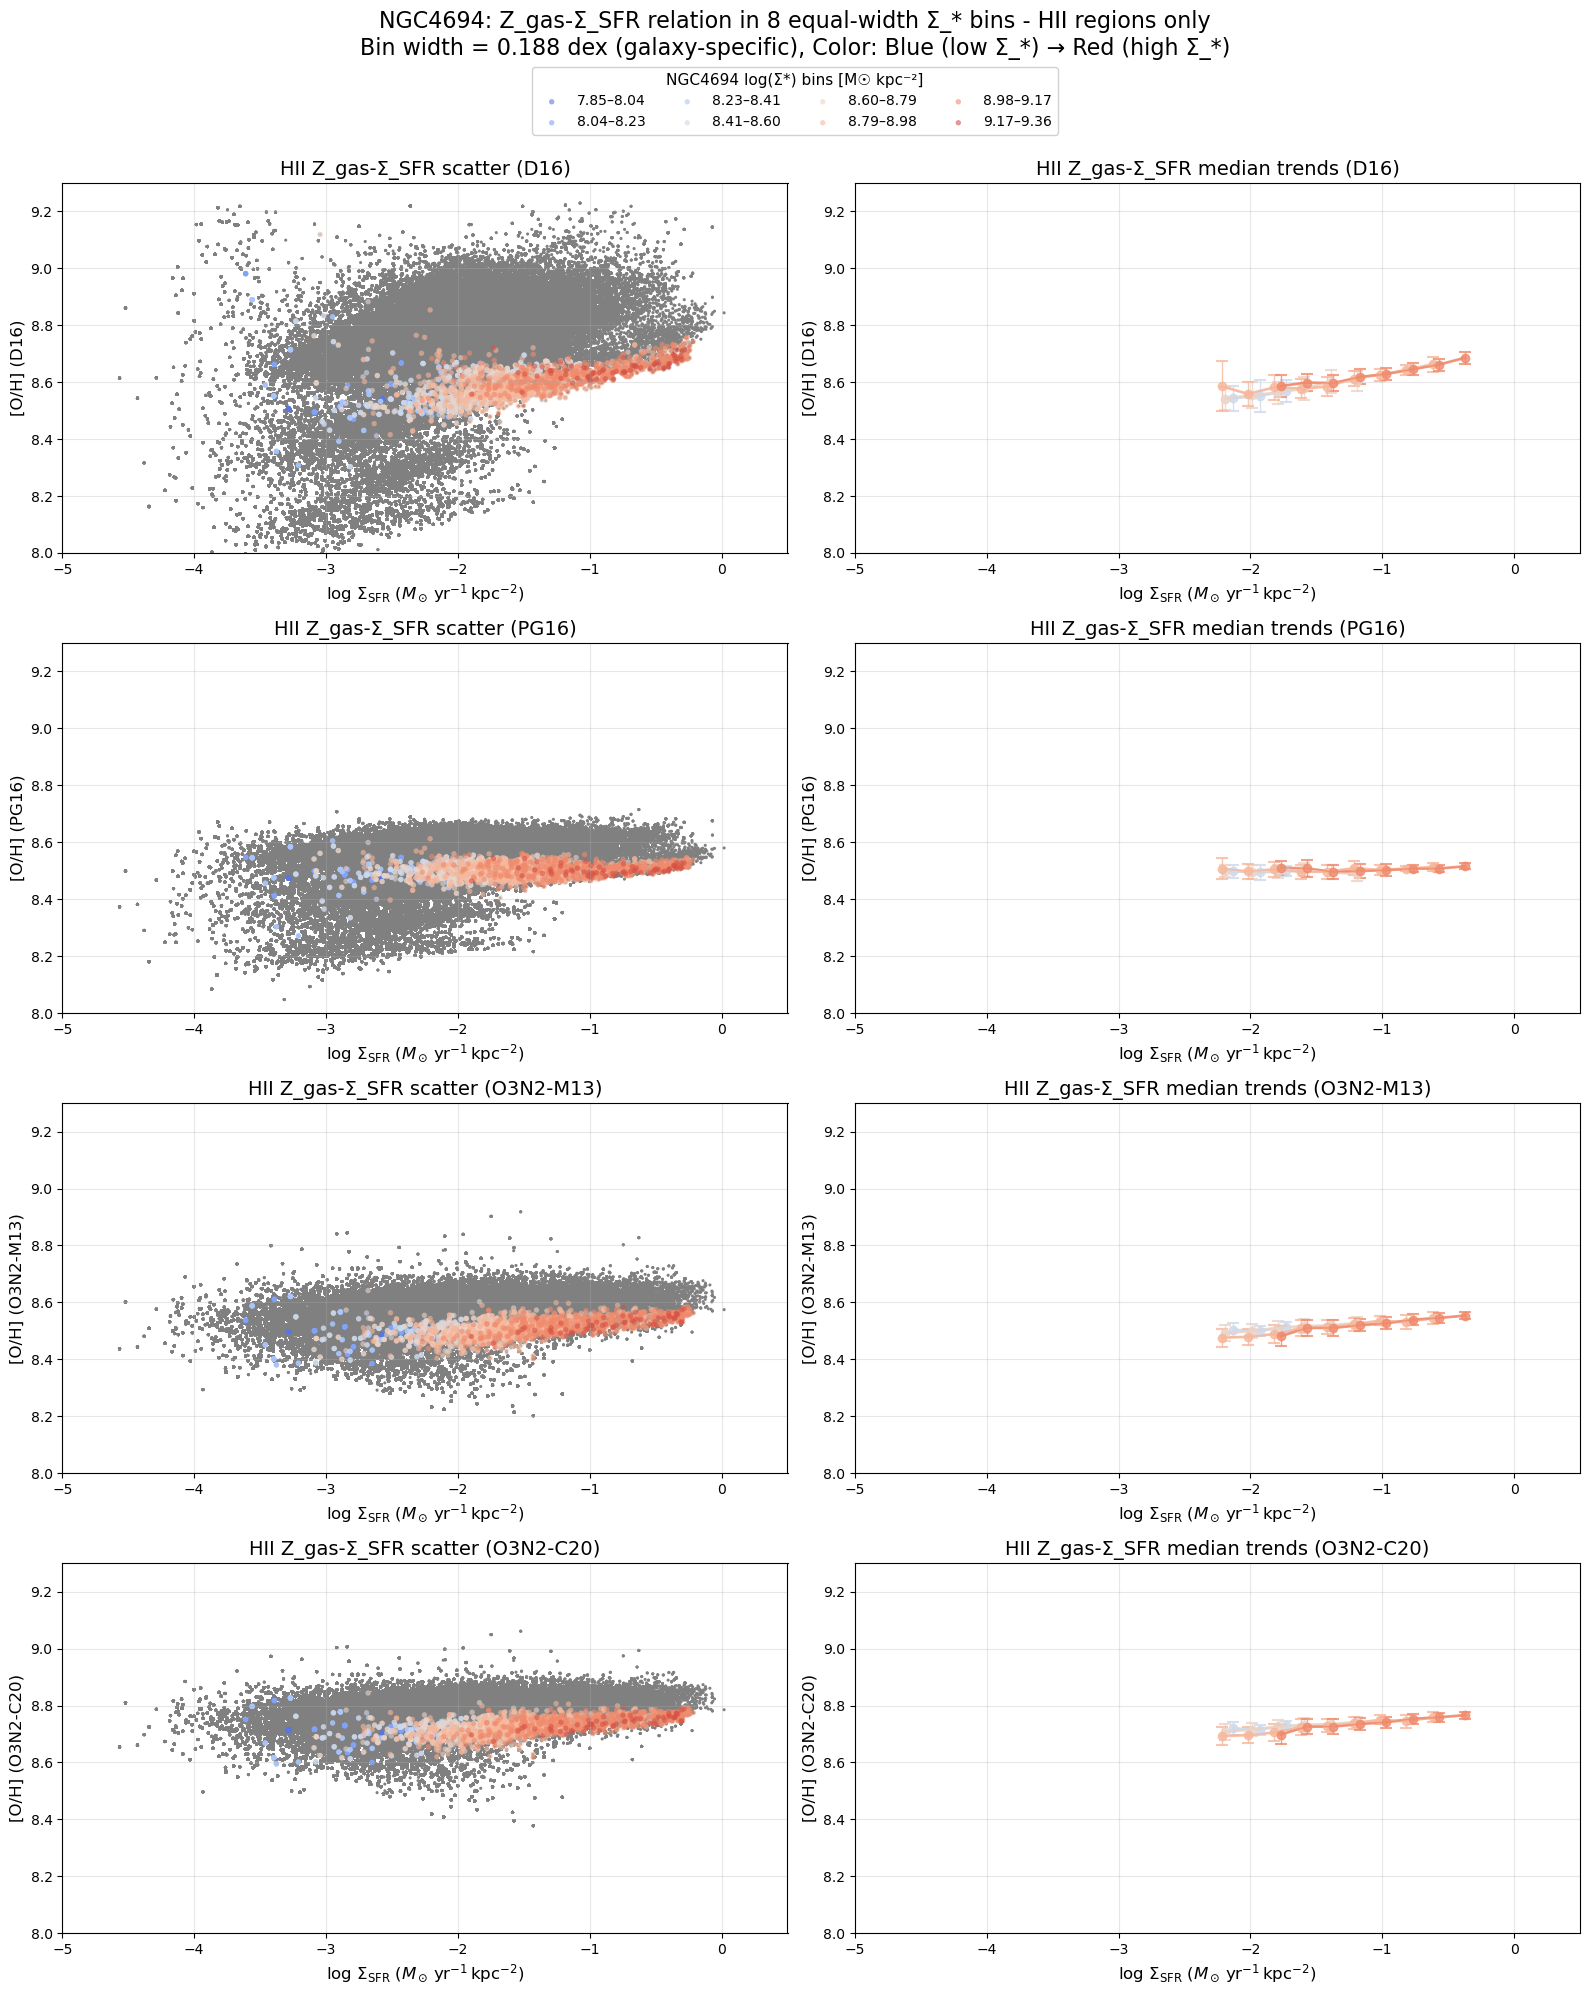


Successfully created 4x2 subplot figure for NGC4694
Binning summary:
  Number of bins: 8
  Bin width: 0.188 dex (equal width)
  Σ_* range: 7.849 to 9.356

Processing galaxy: NGC4698
Total HII pixels with all calibrations: 10042

NGC4698 Σ_* range:
  Min: 7.478
  Max: 9.787
  Range: 2.309

NGC4698 Bin width: 0.289

NGC4698 8 equal-width Σ_* bins:
  Bin edges: ['7.478', '7.767', '8.055', '8.344', '8.633', '8.921', '9.210', '9.498', '9.787']
  Bin 1: 7.48–7.77
  Bin 2: 7.77–8.06
  Bin 3: 8.06–8.34
  Bin 4: 8.34–8.63
  Bin 5: 8.63–8.92
  Bin 6: 8.92–9.21
  Bin 7: 9.21–9.50
  Bin 8: 9.50–9.79

NGC4698 Pixel counts per bin:
  Bin 1 (7.48–7.77): 1206 pixels (12.0%)
  Bin 2 (7.77–8.06): 3846 pixels (38.3%)
  Bin 3 (8.06–8.34): 4000 pixels (39.8%)
  Bin 4 (8.34–8.63): 897 pixels (8.9%)
  Bin 5 (8.63–8.92): 27 pixels (0.3%)
  Bin 6 (8.92–9.21): 3 pixels (0.0%)
  Bin 7 (9.21–9.50): 21 pixels (0.2%)
  Bin 8 (9.50–9.79): 42 pixels (0.4%)

Total pixels in bins: 10042 (should match 10042)

Processin

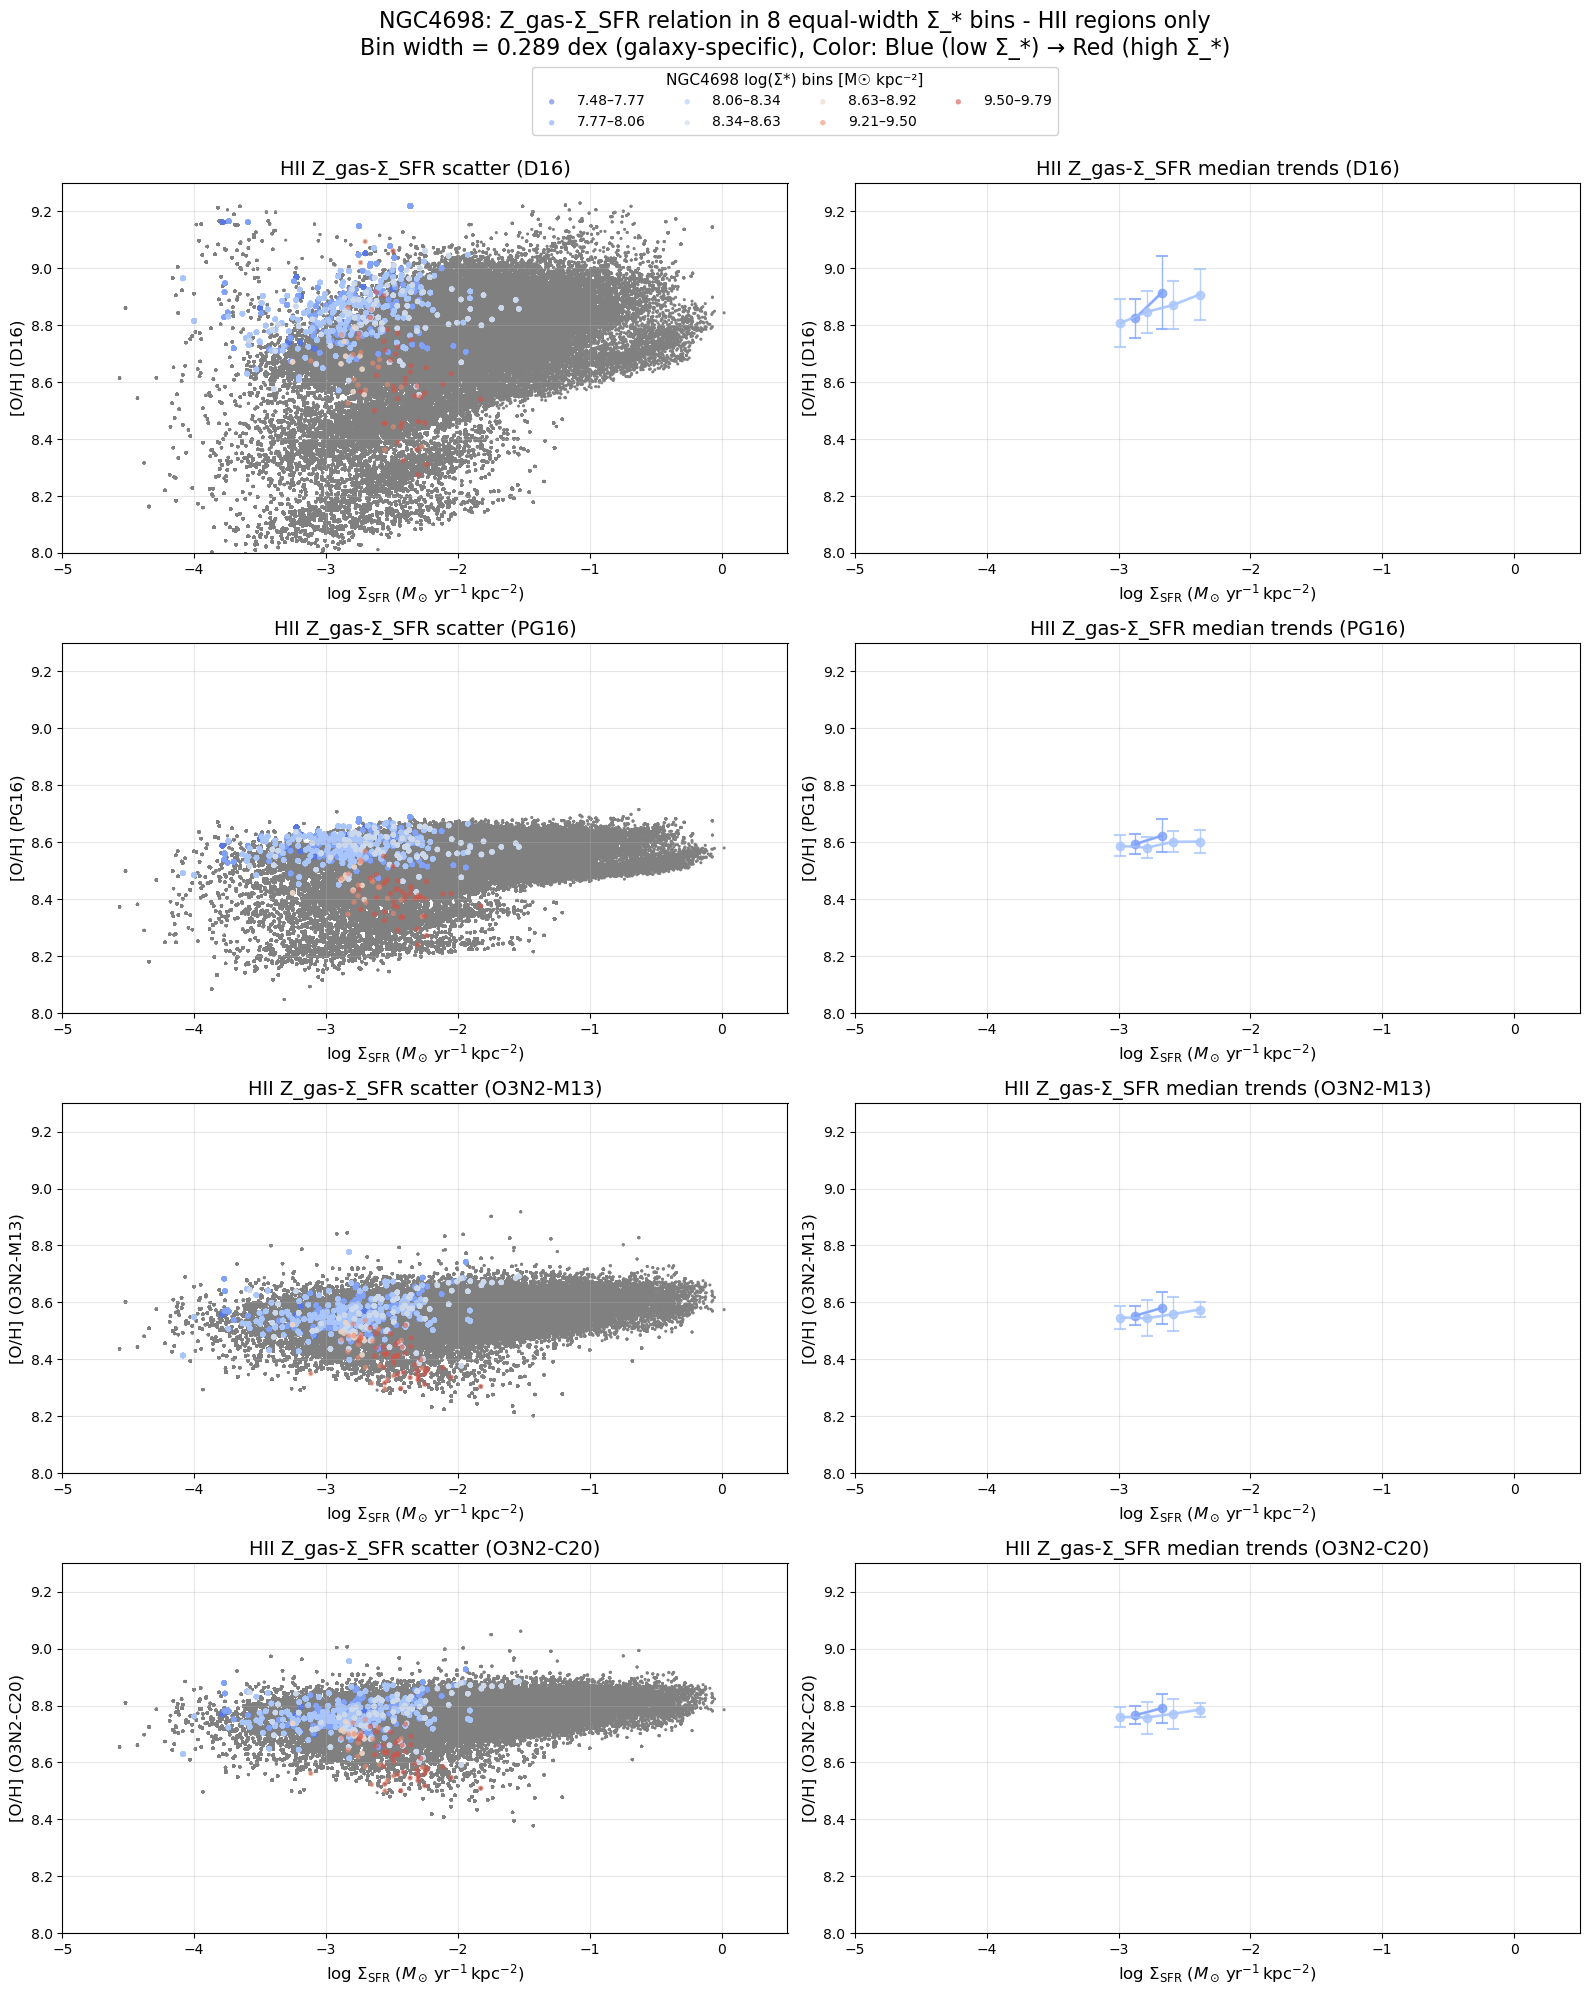


Successfully created 4x2 subplot figure for NGC4698
Binning summary:
  Number of bins: 8
  Bin width: 0.289 dex (equal width)
  Σ_* range: 7.478 to 9.787

Finished processing all galaxies


In [2]:
# ------------------------------------------------------------------
# Individual Galaxy Analysis: Z_gas-Σ_SFR relation in 8 equal-width Σ_* bins - HII regions only
# Loop through each galaxy individually
# Σ_* bins are calculated individually for each galaxy based on its own data
# Using equal bin-width approach
#
# 4 calibrations: D16, PG16, O3N2-M13, O3N2-C20
# Row 1: D16 (scatter left, median right)
# Row 2: PG16 (scatter left, median right)
# Row 3: O3N2-M13 (scatter left, median right)
# Row 4: O3N2-C20 (scatter left, median right)
# ------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.io import fits
import scipy.stats as stats

def load_maps_all_calibrations(gal):
    """Load all metallicity calibrations for HII regions"""
    with fits.open(f'{gal}_SPATIAL_BINNING_maps_extended.fits') as h:
        sigM = h['LOGMASS_SURFACE_DENSITY'].data
    with fits.open(f'{gal}_gas_BIN_maps_extended.fits') as h:
        # HII regions
        sigSFR_HII = h['LOGSFR_SURFACE_DENSITY_HII'].data
        oh_d16_HII = h['O_H_D16_HII'].data
        oh_pg16_HII = h['O_H_PG16_HII'].data
        oh_o3n2_m13_HII = h['O_H_O3N2_M13_HII'].data
        oh_o3n2_c20_HII = h['O_H_O3N2_C20_HII'].data
    return (sigM, sigSFR_HII, oh_d16_HII, oh_pg16_HII, oh_o3n2_m13_HII, oh_o3n2_c20_HII)

def calculate_binned_stats(x_data, y_data, bin_width=0.2, min_pixels=20):
    """Calculate median and std in SFR bins - only keep bins with >= 20 unique datapoints"""
    # Define SFR bins
    x_min, x_max = np.nanmin(x_data), np.nanmax(x_data)
    sfr_bin_edges = np.arange(x_min, x_max + bin_width, bin_width)
    sfr_bin_centers = (sfr_bin_edges[:-1] + sfr_bin_edges[1:]) / 2
    
    medians = []
    stds = []
    counts = []
    valid_centers = []
    valid_bin_indices = []
    
    for i, (bin_start, bin_end) in enumerate(zip(sfr_bin_edges[:-1], sfr_bin_edges[1:])):
        # Select data in this SFR bin
        in_sfr_bin = (x_data >= bin_start) & (x_data < bin_end)
        y_in_bin = y_data[in_sfr_bin]
        
        if len(np.unique(y_in_bin)) >= min_pixels:
            medians.append(np.median(y_in_bin))
            stds.append(np.std(y_in_bin))
            counts.append(len(y_in_bin))
            valid_centers.append(sfr_bin_centers[i])
            valid_bin_indices.append(i)
    
    return (np.array(valid_centers), np.array(medians), np.array(stds), 
            np.array(counts), np.array(valid_bin_indices))

# Get all galaxies
bins = sorted(Path('.').glob('*_SPATIAL_BINNING_maps_extended.fits'))
galaxies = [f.name.split('_')[0] for f in bins]

# Galaxies to exclude entirely
excluded_galaxies = {'NGC4383'}
included_galaxies = []

# ==============================================================================
# First, collect combined data from all galaxies (for background gray scatter)
# ==============================================================================
print("="*80)
print("STEP 1: Collecting combined data from all galaxies for background...")
print("="*80)

all_logSigmaM_HII = []
all_logSigmaSFR_HII = []
all_oh_d16_HII = []
all_oh_pg16_HII = []
all_oh_o3n2_m13_HII = []
all_oh_o3n2_c20_HII = []

for gal in galaxies:
    if gal in excluded_galaxies:
        print(f"  {gal}: excluded from combined dataset")
        continue

    bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')
    gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')

    if bin_file.exists() and gas_file.exists():
        # Load all data for HII regions
        (logSigmaM, logSigmaSFR_HII, oh_d16_HII, oh_pg16_HII, oh_o3n2_m13_HII, 
         oh_o3n2_c20_HII) = load_maps_all_calibrations(gal)

        # Find common spaxels for HII regions
        common_mask_HII = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & 
                           np.isfinite(oh_d16_HII) & np.isfinite(oh_pg16_HII) & 
                           np.isfinite(oh_o3n2_m13_HII) & np.isfinite(oh_o3n2_c20_HII))
        
        print(f"  {gal}: HII={np.sum(common_mask_HII)} pixels")
        
        # Append HII data
        all_logSigmaM_HII.extend(logSigmaM[common_mask_HII].flatten())
        all_logSigmaSFR_HII.extend(logSigmaSFR_HII[common_mask_HII].flatten())
        all_oh_d16_HII.extend(oh_d16_HII[common_mask_HII].flatten())
        all_oh_pg16_HII.extend(oh_pg16_HII[common_mask_HII].flatten())
        all_oh_o3n2_m13_HII.extend(oh_o3n2_m13_HII[common_mask_HII].flatten())
        all_oh_o3n2_c20_HII.extend(oh_o3n2_c20_HII[common_mask_HII].flatten())

# Convert to numpy arrays
all_logSigmaM_HII = np.array(all_logSigmaM_HII)
all_logSigmaSFR_HII = np.array(all_logSigmaSFR_HII)
all_oh_d16_HII = np.array(all_oh_d16_HII)
all_oh_pg16_HII = np.array(all_oh_pg16_HII)
all_oh_o3n2_m13_HII = np.array(all_oh_o3n2_m13_HII)
all_oh_o3n2_c20_HII = np.array(all_oh_o3n2_c20_HII)

# Store combined data in a dictionary for easy access
combined_calib_map = {
    'oh_d16_HII': all_oh_d16_HII,
    'oh_pg16_HII': all_oh_pg16_HII,
    'oh_o3n2_m13_HII': all_oh_o3n2_m13_HII,
    'oh_o3n2_c20_HII': all_oh_o3n2_c20_HII
}

print(f"\nTotal combined pixels (HII): {len(all_logSigmaM_HII)}")

# ==============================================================================
# Define plotting parameters
# ==============================================================================
n_bins = 8

# Set uniform y-axis range
common_ylim = (8.0, 9.3)

print(f"\nUsing uniform y-axis range: {common_ylim[0]:.1f} to {common_ylim[1]:.1f}")

# Data for each calibration
calibrations = [
    ('oh_d16_HII', 'D16'),
    ('oh_pg16_HII', 'PG16'),
    ('oh_o3n2_m13_HII', 'O3N2-M13'),
    ('oh_o3n2_c20_HII', 'O3N2-C20')
]

# ==============================================================================
# STEP 2: Loop through each galaxy and plot individual data + combined background
# ==============================================================================
print("\n" + "="*80)
print("STEP 2: Processing individual galaxies...")
print("="*80)

for gal in galaxies:
    if gal in excluded_galaxies:
        print(f"\n{'='*80}")
        print(f"Skipping {gal} (excluded from analysis)")
        print(f"{'='*80}")
        continue

    bin_file = Path(f'{gal}_SPATIAL_BINNING_maps_extended.fits')
    gas_file = Path(f'{gal}_gas_BIN_maps_extended.fits')

    if not (bin_file.exists() and gas_file.exists()):
        print(f"\n{'='*80}")
        print(f"Skipping {gal} (data files not found)")
        print(f"{'='*80}")
        continue

    print(f"\n{'='*80}")
    print(f"Processing galaxy: {gal}")
    print(f"{'='*80}")

    # Load all data for this galaxy
    (logSigmaM, logSigmaSFR_HII, oh_d16_HII, oh_pg16_HII, oh_o3n2_m13_HII, 
     oh_o3n2_c20_HII) = load_maps_all_calibrations(gal)

    # Find common spaxels for HII regions
    common_mask_HII = (np.isfinite(logSigmaM) & np.isfinite(logSigmaSFR_HII) & 
                       np.isfinite(oh_d16_HII) & np.isfinite(oh_pg16_HII) & 
                       np.isfinite(oh_o3n2_m13_HII) & np.isfinite(oh_o3n2_c20_HII))
    
    n_pixels_total = np.sum(common_mask_HII)
    print(f"Total HII pixels with all calibrations: {n_pixels_total}")
    
    if n_pixels_total == 0:
        print(f"No valid pixels for {gal}, skipping...")
        continue

    # Get flattened arrays for this galaxy
    gal_logSigmaM = logSigmaM[common_mask_HII].flatten()
    gal_logSigmaSFR_HII = logSigmaSFR_HII[common_mask_HII].flatten()
    gal_oh_d16_HII = oh_d16_HII[common_mask_HII].flatten()
    gal_oh_pg16_HII = oh_pg16_HII[common_mask_HII].flatten()
    gal_oh_o3n2_m13_HII = oh_o3n2_m13_HII[common_mask_HII].flatten()
    gal_oh_o3n2_c20_HII = oh_o3n2_c20_HII[common_mask_HII].flatten()

    # ==============================================================================
    # Calculate 8 equal-width Σ_* bins for THIS GALAXY based on its own data range
    # ==============================================================================
    gal_sigmaM_min = np.min(gal_logSigmaM)
    gal_sigmaM_max = np.max(gal_logSigmaM)
    gal_sigmaM_range = gal_sigmaM_max - gal_sigmaM_min
    
    print(f"\n{gal} Σ_* range:")
    print(f"  Min: {gal_sigmaM_min:.3f}")
    print(f"  Max: {gal_sigmaM_max:.3f}")
    print(f"  Range: {gal_sigmaM_range:.3f}")
    
    # Define 8 bins with equal width for this galaxy
    gal_bin_width = gal_sigmaM_range / n_bins
    
    print(f"\n{gal} Bin width: {gal_bin_width:.3f}")
    
    # Create bin edges using equal width
    gal_sigmaM_bin_edges = np.linspace(gal_sigmaM_min, gal_sigmaM_max, n_bins + 1)
    
    # Create bin labels with actual values for this galaxy
    gal_bin_labels = []
    for i in range(n_bins):
        gal_bin_labels.append(f'{gal_sigmaM_bin_edges[i]:.2f}–{gal_sigmaM_bin_edges[i+1]:.2f}')
    
    print(f"\n{gal} 8 equal-width Σ_* bins:")
    print(f"  Bin edges: {[f'{edge:.3f}' for edge in gal_sigmaM_bin_edges]}")
    for i, label in enumerate(gal_bin_labels):
        print(f"  Bin {i+1}: {label}")
    
    # Verify bin counts for this galaxy
    print(f"\n{gal} Pixel counts per bin:")
    total_check = 0
    for i in range(n_bins):
        if i == 0:
            mask = (gal_logSigmaM >= gal_sigmaM_bin_edges[i]) & (gal_logSigmaM < gal_sigmaM_bin_edges[i+1])
        elif i == n_bins - 1:
            mask = (gal_logSigmaM >= gal_sigmaM_bin_edges[i]) & (gal_logSigmaM <= gal_sigmaM_bin_edges[i+1])
        else:
            mask = (gal_logSigmaM >= gal_sigmaM_bin_edges[i]) & (gal_logSigmaM < gal_sigmaM_bin_edges[i+1])
        count = np.sum(mask)
        pct = 100 * count / len(gal_logSigmaM)
        total_check += count
        print(f"  Bin {i+1} ({gal_bin_labels[i]}): {count} pixels ({pct:.1f}%)")
    
    print(f"\nTotal pixels in bins: {total_check} (should match {len(gal_logSigmaM)})")
    
    # Colors for 8 bins: gradient from blue (low Σ_*) to red (high Σ_*)
    colors = plt.cm.coolwarm(np.linspace(0.1, 0.9, n_bins))

    # Map calibration variable names to actual data for this galaxy
    calib_data_map = {
        'oh_d16_HII': gal_oh_d16_HII,
        'oh_pg16_HII': gal_oh_pg16_HII,
        'oh_o3n2_m13_HII': gal_oh_o3n2_m13_HII,
        'oh_o3n2_c20_HII': gal_oh_o3n2_c20_HII
    }

    # Create figure with 4 rows x 2 columns 
    fig, axes = plt.subplots(4, 2, figsize=(16, 20))

    # Create legend handles (will be populated during first row)
    legend_handles = []
    legend_labels = []

    # Process each row (1 calibration per row)
    for row_idx, (calib_key, calib_name_HII) in enumerate(calibrations):
        print(f"\nProcessing {calib_name_HII} calibration for HII regions:")
        
        # Get the data for this calibration (individual galaxy)
        oh_data_HII = calib_data_map[calib_key]
        
        # Get the combined data for this calibration (all galaxies)
        oh_combined_HII = combined_calib_map[calib_key]
        
        # Column 0: Scatter plot, Column 1: Median trends
        ax_scatter = axes[row_idx, 0]
        ax_median = axes[row_idx, 1]
        
        print(f"  HII {calib_name_HII} range: {np.min(oh_data_HII):.3f} to {np.max(oh_data_HII):.3f}")
        
        # FIRST: Plot combined galaxy data as gray background
        ax_scatter.scatter(all_logSigmaSFR_HII, oh_combined_HII, 
                         c='gray', s=5, alpha=1.0, edgecolors='none', 
                         rasterized=True, label='All galaxies')
        
        # SECOND: Plot each Σ_* bin for this individual galaxy
        valid_bins = 0
        
        for i in range(n_bins):
            # HII regions processing - handle edge cases for first and last bins
            # Use THIS GALAXY's bin edges (equal-width)
            if i == 0:
                in_bin_HII = (gal_logSigmaM >= gal_sigmaM_bin_edges[i]) & (gal_logSigmaM < gal_sigmaM_bin_edges[i+1])
            elif i == n_bins - 1:
                in_bin_HII = (gal_logSigmaM >= gal_sigmaM_bin_edges[i]) & (gal_logSigmaM <= gal_sigmaM_bin_edges[i+1])
            else:
                in_bin_HII = (gal_logSigmaM >= gal_sigmaM_bin_edges[i]) & (gal_logSigmaM < gal_sigmaM_bin_edges[i+1])
            
            n_pixels_HII = np.sum(in_bin_HII)
            
            if n_pixels_HII >= 10:  # Process bins with enough pixels
                # Get data for this bin - NOW: x=Σ_SFR, y=[O/H]
                x_bin_HII = gal_logSigmaSFR_HII[in_bin_HII]
                y_bin_HII = oh_data_HII[in_bin_HII]
                
                # Scatter plot (individual galaxy on top of gray background)
                scatter_hii = ax_scatter.scatter(x_bin_HII, y_bin_HII, c=[colors[i]], s=15, alpha=0.6, 
                                     edgecolors='none', rasterized=True)
                
                # Collect legend info only from first row
                if row_idx == 0 and len(legend_handles) < n_bins:
                    legend_handles.append(scatter_hii)
                    legend_labels.append(gal_bin_labels[i])
                
                # Median trends
                sfr_centers_HII, medians_HII, stds_HII, counts_HII, valid_bin_indices_HII = calculate_binned_stats(
                    x_bin_HII, y_bin_HII, bin_width=0.2, min_pixels=20)
                
                if len(sfr_centers_HII) > 0:
                    ax_median.errorbar(sfr_centers_HII, medians_HII, yerr=stds_HII, 
                               color=colors[i], marker='o', markersize=6, 
                               linewidth=1, capsize=4, capthick=1.5, alpha=0.8)
                    
                    # Add lines between adjacent bins
                    for j in range(len(valid_bin_indices_HII) - 1):
                        current_bin_idx = valid_bin_indices_HII[j]
                        next_bin_idx = valid_bin_indices_HII[j + 1]
                        if next_bin_idx - current_bin_idx == 1:
                            ax_median.plot([sfr_centers_HII[j], sfr_centers_HII[j + 1]], 
                                   [medians_HII[j], medians_HII[j + 1]], 
                                   color=colors[i], linewidth=2, alpha=0.8)
                    valid_bins += 1
        
        # Format scatter plot
        ax_scatter.set_xlabel(r'$\log\,\Sigma_\mathrm{SFR} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)
        ax_scatter.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
        ax_scatter.set_title(f'HII Z_gas-Σ_SFR scatter ({calib_name_HII})', fontsize=14)
        ax_scatter.grid(True, alpha=0.3)
        ax_scatter.set_xlim(-5.0, 0.5)
        ax_scatter.set_ylim(common_ylim)
        
        # Format median trends plot
        ax_median.set_xlabel(r'$\log\,\Sigma_\mathrm{SFR} \; (M_\odot\,\mathrm{yr}^{-1}\,\mathrm{kpc}^{-2})$', fontsize=12)
        ax_median.set_ylabel(f'[O/H] ({calib_name_HII})', fontsize=12)
        ax_median.set_title(f'HII Z_gas-Σ_SFR median trends ({calib_name_HII})', fontsize=14)
        ax_median.grid(True, alpha=0.3)
        ax_median.set_xlim(-5.0, 0.5)
        ax_median.set_ylim(common_ylim)
        
        print(f"  Total valid bins: {valid_bins}")

    # Add overall title and adjust layout
    fig.suptitle(f'{gal}: Z_gas-Σ_SFR relation in 8 equal-width Σ_* bins - HII regions only\n' + 
                 f'Bin width = {gal_bin_width:.3f} dex (galaxy-specific), Color: Blue (low Σ_*) → Red (high Σ_*)', 
                 fontsize=16, y=0.995)

    # Add shared legend at the top horizontally
    fig.legend(legend_handles, legend_labels, loc='upper center', bbox_to_anchor=(0.5, 0.97),
              ncol=4, fontsize=10, framealpha=0.9, 
              title=f'{gal} log(Σ*) bins [M☉ kpc⁻²]', title_fontsize=11)

    plt.tight_layout(rect=[0, 0, 1, 0.96])  # Leave space for suptitle and legend
    # plt.savefig(f'{gal}_Zgas_SigmaSFR_HII_8bins_equalwidth_pergalaxy_4x2grid.png', dpi=300, bbox_inches='tight')
    # plt.savefig(f'{gal}_Zgas_SigmaSFR_HII_8bins_equalwidth_pergalaxy_4x2grid.pdf', bbox_inches='tight')
    plt.show()

    print(f"\nSuccessfully created 4x2 subplot figure for {gal}")
    print(f"Binning summary:")
    print(f"  Number of bins: {n_bins}")
    print(f"  Bin width: {gal_bin_width:.3f} dex (equal width)")
    print(f"  Σ_* range: {gal_sigmaM_min:.3f} to {gal_sigmaM_max:.3f}")

print(f"\n{'='*80}")
print("Finished processing all galaxies")
print(f"{'='*80}")
